# **Pre-processing Image**
*Lưu ý: Notebook được thực hiện trên môi trường Google Colab tại [link](https://colab.research.google.com/drive/1-8hYTemyi4uPbqnrbnrJSZnM45kiS5dV?usp=sharing)*
## Mục lục
- [0. Cài đặt & Khai báo thư viện](#0)
- [1. Thay đổi kích thước và chất lượng ảnh](#1)
  - 1.1. Lý thuyết và Kỹ thuật
  - 1.2. Tính SSIM và PSNR
  - 1.3. Phân tích kết quả mức độ mất mát thông tin
  - 1.4. Ablation Study – Đánh giá tác động kích thước
  - 1.5. Phân tích kết quả Ablation
  - 1.6. Kết luận & Lựa chọn kích thước
- [2. Chuyển đổi không gian màu](#2)
  - 2.1. Lý thuyết và Kỹ thuật
  - 2.2. Đo lường phương sai giải thích (PCA k=50)
  - 2.3. Phân tích kết quả PCA Explained Variance
  - 2.4. Ablation Study cho Không gian màu
  - 2.5. Phân tích kết quả Ablation
  - 2.6. Kết luận & Lựa chọn không gian màu
- [3. Chuẩn hóa pixel (Normalization)](#3)
  - 3.0. Load ảnh với tham số kế thừa
  - 3.1. Lý thuyết và Công thức
  - 3.2. Kiểm định Kolmogorov-Smirnov (KS Test)
  - 3.3. Trực quan hóa phân phối pixel
  - 3.4. Ablation Study: Đánh giá tác động
  - 3.5. Phân tích kết quả
  - 3.6. Kết luận & Lựa chọn phương pháp chuẩn hóa
- [4. Tăng cường dữ liệu (Data Augmentation)](#4)
  - 4.1. Lý thuyết và Thiết kế Pipeline
  - 4.2. Trực quan hóa kết quả augmentation
  - 4.3. Tạo tập Augmented toàn bộ ~14.000 ảnh
  - 4.4. So sánh phân phối pixel gốc và augmented
  - 4.5. So sánh phân phối đặc trưng bằng t-SNE
  - 4.6. Ablation Study: Tác động của Augmentation
  - 4.7. Phân tích kết quả
- [5. Phân tích PCA nâng cao](#5)
  - 5.1. Giới thiệu về Scree Plot
  - 5.2. Phân tích Scree Plot
  - 5.3. Trực quan hóa PCA 2D
  - 5.4. Phân tích PCA 2D
  - 5.5. Phân tích t-SNE 2D
  - 5.6. Trực quan hóa PCA 3D và t-SNE 3D
  - 5.7. Phân tích PCA 3D
  - 5.8. Phân tích t-SNE 3D
- [6. Phát hiện cạnh và đặc trưng cục bộ (Nâng cao)](#6)
  - 6.0. Cấu hình kế thừa
  - 6.1. Load và transform data
  - 6.2. Khái niệm Phát hiện Cạnh (Edge Detection)
  - 6.4. Kết luận – Thông tin cạnh có phân biệt được các lớp không?


## 0. Cài đặt & Khai báo thư viện <a id='0'></a>

In [ ]:
!pip install torchmetrics -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 26.7 MB/s eta 0:00:00


In [ ]:
# Core
import gc
import os
import random
import time
import warnings
from pathlib import Path

# Data / visualization
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Parallel
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm

# Statistics / ML
from scipy import stats
from sklearn.model_selection import train_test_split
from scipy.stats import gaussian_kde, ks_2samp
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler

# PyTorch
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

# Image quality metrics (GPU)
from torchmetrics.functional.image import (
    peak_signal_noise_ratio as psnr_gpu,
    structural_similarity_index_measure as ssim_gpu,
)

warnings.filterwarnings("ignore")

# Global seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"DEVICE : {device}")
print(f"SEED   : {SEED}")


DEVICE : cuda
SEED   : 42


In [ ]:
import gdown
import os

file_id = '13c4pJxSI48C9i-TZVG6yxf4YJvOhK2xL'
# Dữ liệu đã được EDA và light pre-processing
url = f'https://drive.google.com/uc?id={file_id}'
output = 'intel_dataset.zip'

gdown.download(url, output, quiet=False)

if output.endswith('.zip'):
    extract_path = '/content/intel-image-classification'
    os.makedirs(extract_path, exist_ok=True)
    print(f"Đang giải nén vào {extract_path}...")
    !unzip -q {output} -d {extract_path}
    print("[SUCCESS] Đã tải và giải nén hoàn tất.")


Downloading...
From (original): https://drive.google.com/uc?id=13c4pJxSI48C9i-TZVG6yxf4YJvOhK2xL
From (redirected): https://drive.google.com/uc?id=13c4pJxSI48C9i-TZVG6yxf4YJvOhK2xL&confirm=t&uuid=1a73ddcd-ba18-4953-b3d2-a62d969e28a8
To: /content/intel_dataset.zip
100%|██████████| 361M/361M [00:06<00:00, 52.8MB/s]


Đang giải nén vào /content/intel-image-classification...
[SUCCESS] Đã tải và giải nén hoàn tất.


In [ ]:
train_directory = '/content/intel-image-classification/seg_train/seg_train'
classes = sorted(os.listdir(train_directory))
image_paths = []
labels = []

for category in classes:
    category_path = os.path.join(train_directory, category)
    if os.path.isdir(category_path):
        for image_name in os.listdir(category_path):
            image_paths.append(os.path.join(category_path, image_name))
            labels.append(category)

le = LabelEncoder()
labels_enc = le.fit_transform(labels)
N_TOTAL = len(image_paths)

print(f"Tổng số ảnh tập train: {N_TOTAL}")
print(f"Tổng số lớp phân loại: {len(classes)}")
print(f"Lớp phân loại: {classes}")


Tổng số ảnh tập train: 13974
Tổng số lớp phân loại: 6
Lớp phân loại: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


---
## 1. Thay đổi kích thước và chất lượng ảnh <a id='1'></a>

### 1.1. Lý thuyết và Kỹ thuật thay đổi kích thước ảnh (Image Resizing)
<div align="justify">

Thay đổi kích thước (Resize) là hành động thay đổi kích thước tổng thể của bức ảnh — tức là thay đổi chiều rộng và chiều cao của ảnh mà vẫn giữ lại toàn bộ nội dung bên trong. Đây kỹ thuật tiền xử lý cơ bản giúp giảm số lượng đặc trưng (features) đầu vào, từ đó giảm chi phí tính toán và bộ nhớ cho các mô hình học máy đơn giản như k-NN hay Logistic Regression. Tuy nhiên, việc thu nhỏ ảnh (downsampling) sẽ làm mất đi các chi tiết tần số cao (độ sắc nét, vân bề mặt).

Để đánh giá lượng thông tin bị mất khi thu nhỏ ảnh, ta sẽ mô phỏng quá trình này bằng cách thu nhỏ ảnh gốc từ định dạng 150x150 xuống các kích thước $N \times N$ (ví dụ 32, 64, 128), sau đó phóng to (upscale) ngược lại lên 150x150 để so sánh với ảnh gốc.
### 1.2 Các độ đo đánh giá chất lượng ảnh
**1. SSIM (Structural Similarity Index)**

Chỉ số SSIM được sử dụng để đo mức độ giống nhau giữa 2 hình ảnh (hoặc ảnh đầu vào và ảnh sinh ra trong bài toán sinh ảnh). Công thức SSIM dựa trên ba thông số để so sánh: độ chói (luminance), tương phản (contrast) và cấu trúc (structure):
$$SSIM(x,y) = \frac{(2\mu_x\mu_y + c_1)(2\sigma_{xy} + c_2)}{(\mu_x^2 + \mu_y^2 + c_1)(\sigma_x^2 + \sigma_y^2 + c_2)}$$

Trong đó:

* $\mu_x, \mu_y$: Độ sáng trung bình của 2 ảnh $x$ và $y$ (đánh giá độ chói).
* $\sigma_x^2, \sigma_y^2$: Phương sai của ảnh $x$ và $y$ (đánh giá độ tương phản).
* $\sigma_{xy}$: Hiệp phương sai của $x$ và $y$ (đánh giá sự tương đồng cấu trúc).
* $c_1, c_2$: Các hằng số ổn định để tránh mẫu số bằng 0.

**Ý nghĩa**: SSIM có giá trị trong khoảng từ -1 đến 1, đạt giá trị bằng 1 trong trường hợp hai ảnh giống hệt nhau. Chỉ số này có giá trị càng lớn thì độ tương đồng càng tốt.

**2. PSNR**

PSNR đo lường tỷ lệ giữa công suất tín hiệu tối đa của ảnh và công suất nhiễu (sai số giữa ảnh gốc và ảnh nén). PSNR càng cao, chất lượng ảnh khôi phục càng tốt.
Công thức tính dựa trên sai số toàn phương trung bình (MSE - Mean Squared Error):
$$MSE = \frac{1}{m \cdot n} \sum_{i=0}^{m-1} \sum_{j=0}^{n-1} [I(i,j) - K(i,j)]^2$$

$$PSNR = 10 \cdot \log_{10} \left( \frac{MAX_I^2}{MSE} \right)$$

Trong đó:
* $I$ là ảnh gốc, $K$ là ảnh đã qua xử lý (phóng to lại từ kích thước nhỏ).
* $m, n$: là kích thước ảnh.
* $MAX_I$: là giá trị pixel lớn nhất trên ảnh(bằng 255 với ảnh 8-bit hoặc $2^B - 1$ với ảnh B bit)

**Ý nghĩa**: Thông thường, nếu PSNR ≥ 40 dB thì mắt người gần như không thể phân biệt sự khác biệt giữa hai ảnh. PSNR càng cao thì hai ảnh càng giống nhau về mặt chất lượng. Khi hai ảnh giống hệt nhau thì MSE = 0 và PSNR tiến đến vô hạn. Đơn vị của PSNR là decibel (dB).

</div>


### 1.2. Tính SSIM và PSNR theo từng kích thước

 Đang chạy trên: cuda | Số lượng ảnh: 13974


[GPU]: 100%|██████████| 110/110 [00:14<00:00,  7.49it/s]



_____________________________________________
Size       | Mean SSIM       | Mean PSNR (dB)
_____________________________________________
32x32      | 0.47            | 19.57
64x64      | 0.62            | 21.21
128x128     | 0.80            | 23.56
_____________________________________________


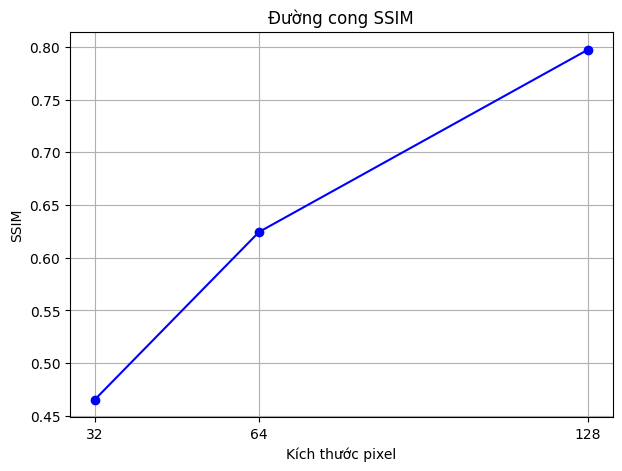

In [ ]:
class MetricDataset(Dataset):
    def __init__(self, paths, orig_size=(150, 150)):
        self.paths = paths
        self.orig_size = orig_size

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        try:
            img = cv2.imread(self.paths[idx])
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, self.orig_size)
            return torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
        except:
            return torch.zeros((3, self.orig_size[0], self.orig_size[1]))

def compute_metrics_gpu(image_paths, target_sizes=[32, 64, 128], orig_size=(150, 150)):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    dataset = MetricDataset(image_paths, orig_size=orig_size)
    loader = DataLoader(dataset, batch_size=128, num_workers=os.cpu_count(), pin_memory=True)

    results_ssim = {size: 0.0 for size in target_sizes}
    results_psnr = {size: 0.0 for size in target_sizes}
    total_samples = 0

    print(f" Đang chạy trên: {device} | Số lượng ảnh: {len(image_paths)}")

    with torch.inference_mode():
        for batch_orig in tqdm(loader, desc="[GPU]"):
            batch_orig = batch_orig.to(device, non_blocking=True)
            batch_size = batch_orig.size(0)
            total_samples += batch_size

            for size in target_sizes:
                batch_low = F.interpolate(batch_orig, size=(size, size), mode='area')
                batch_up = F.interpolate(batch_low, size=orig_size, mode='bicubic', align_corners=False)
                batch_up = torch.clamp(batch_up, 0, 1)

                s_val = ssim_gpu(batch_up, batch_orig, data_range=1.0)
                p_val = psnr_gpu(batch_up, batch_orig, data_range=1.0)

                results_ssim[size] += s_val.item() * batch_size
                results_psnr[size] += p_val.item() * batch_size

    mean_ssim = {s: v / total_samples for s, v in results_ssim.items()}
    mean_psnr = {s: v / total_samples for s, v in results_psnr.items()}

    return mean_ssim, mean_psnr

def plot_ssim_curve(target_sizes, mean_ssim):
    x = target_sizes
    y = [mean_ssim[s] for s in target_sizes]
    plt.figure(figsize=(7, 5))
    plt.plot(x, y, 'b-o')
    plt.title("Đường cong SSIM")
    plt.xlabel("Kích thước pixel")
    plt.ylabel("SSIM")
    plt.xticks(x)
    plt.grid(True)
    plt.show()

target_sizes = [32, 64, 128]
mean_ssim, mean_psnr = compute_metrics_gpu(image_paths, target_sizes=target_sizes)

print("\n" + "_"*45)
print(f"{'Size':<10} | {'Mean SSIM':<15} | {'Mean PSNR (dB)':<10}")
print("_" * 45)
for s in target_sizes:
    print(f"{s}x{s:<7} | {mean_ssim[s]:<15.2f} | {mean_psnr[s]:.2f}")
print("_"*45)
plot_ssim_curve(target_sizes, mean_ssim)


### 1.3. Phân tích kết quả mức độ mất mát thông tin do thay đổi kích thước
<div align="justify">

Dựa vào bảng kết quả đo lường định lượng từ hai chỉ số SSIM và PSNR đối với 3 độ phân giải (32x32, 64x64, 128x128) so với ảnh gốc (150x150), ta có thể rút ra các nhận xét sau

**1. Đánh giá xu hướng chung**

Cả hai chỉ số SSIM (thể hiện độ toàn vẹn cấu trúc) và PSNR (thể hiện chất lượng tín hiệu điểm ảnh) đều sụt giảm tỷ lệ thuận với kích thước ảnh. Quá trình hạ lấy mẫu (downsampling) càng sâu, mức độ thất thoát thông tin và biến dạng dữ liệu càng lớn.

**2. Phân tích theo chỉ số SSIM (Structural Similarity Index)**
*   128x128 (SSIM ≈ 0.80): Mức độ giữ lại cấu trúc đạt gần 80%, Vì kích thước này rất gần với ảnh gốc nguyên bản, hầu hết cấu trúc không gian và chi tiết cảnh quan (như góc cạnh tòa nhà, gợn sóng biển, tán cây) được bảo toàn rất tốt. Ảnh hầu như không bị biến dạng về mặt tổng thể. Mắt người và cả mô hình học máy vẫn dễ dàng nhận ra các chi tiết như ô cửa sổ của tòa nhà hay các rãnh nứt trên sông băng (glacier).

*   64x64 (SSIM ≈ 0.62): Mức độ tương đồng cấu trúc bắt đầu giảm rõ rệt. Các chi tiết nhỏ (viền lá cây, gợn sóng biển) đã bị làm mờ (blur), nhưng các khối cấu trúc lớn như hình dáng ngọn núi hay dải phân cách đường phố (street) vẫn được bảo toàn đủ tốt để làm vệt ranh giới quyết định (decision boundary) cho bộ phân loại.

*   32x32 (SSIM ≈ 0.47): Giá trị SSIM sụt giảm xuống dưới mức 0.5, báo hiệu cấu trúc không gian đã bị phá vỡ nghiêm trọng. Ảnh bị "vỡ", mờ đi rõ rệt, các chi tiết nhỏ bị hòa lẫn vào nhau. Điểm số thấp này báo hiệu rằng mô hình sẽ gặp khó khăn lớn trong việc nhận diện hình dáng vật thể ban đầu.

**3. Phân tích theo chỉ số PSNR**
*   Tại 128x128 (23.56 dB) và 64x64 (21.21 dB): PSNR vẫn duy trì trên ngưỡng 20 dB - một ngưỡng an toàn và chấp nhận được trong xử lý ảnh chuẩn đoán. Mặc dù có sự sai lệch màu sắc cục bộ, nhưng nhìn chung "tín hiệu" (thông tin thực của ảnh) vẫn áp đảo "nhiễu" (sai số do resize).
*    32x32 (19.57 dB): PSNR rơi xuống dưới 20 dB. Ở mức này, sự trộn lẫn màu sắc (color blending) giữa các pixel lân cận diễn ra cực kỳ mạnh. Ví dụ, màu xanh của rừng (forest) và màu xám của đường phố (street) có thể bị pha trộn thành các mảng màu bệt, làm mất đi tính đại diện của phân bố màu (Color Histogram).

**4. Nhận xét tổng quát**
*   **Đánh đổi giữa Chi phí tính toán và Chất lượng thông tin (Trade-off)**: Việc sử dụng kích thước 128x128 mang lại dữ liệu phong phú nhất, đảm bảo độ chính xác cao nhưng lại đòi hỏi chi phí tính toán (RAM, thời gian huấn luyện) lớn hơn nhiều lần. Ngược lại, 32x32 giúp mô hình huấn luyện cực nhanh, nhưng độ chính xác dự báo chắc chắn sẽ sụt giảm mạnh do mô hình thiếu hụt các manh mối trực quan (visual cues) cần thiết để phân biệt các lớp phức tạp.
*   **Điểm cân bằng (Sweet spot)**: Kích thước 64x64 thường được xem là điểm rơi lý tưởng. Nó giúp giảm tới hơn 80% số lượng pixel so với ảnh 150x150 (từ 22,500 xuống còn 4,096 pixels) giúp tăng tốc độ huấn luyện đáng kể, trong khi vẫn giữ lại đủ mức thông tin cấu trúc (SSIM > 0.6) để mô hình có thể đạt được độ chính xác phân loại tương đối tốt.
</div>


### 1.4. Ablation Study – Đánh giá tác động kích thước đến hiệu năng phân loại



Pipeline: Load uint8 (150×150) → Resize → Flatten /255 → PCA(200, randomized, `random_state=SEED`) → k-NN (k=5) và LR (lbfgs, `random_state=SEED`).


In [ ]:
#  CONFIG
CLASSES      = ["buildings", "forest", "glacier", "mountain", "sea", "street"]
CLASS_LABELS = {c: i for i, c in enumerate(CLASSES)}
BASE_DIR     = Path("intel-image-classification")
TRAIN_DIR    = BASE_DIR / "seg_train" / "seg_train"
TEST_DIR     = BASE_DIR / "seg_test"  / "seg_test"
SIZES        = [32, 64, 128, 150]
KNN_K        = 5
LR_MAX_ITER  = 1000
PCA_VARIANCE = 0.9
N_WORKERS    = min(8, os.cpu_count() or 4)


In [ ]:
def _read_one(args):
    path, label = args
    img = cv2.imread(path)
    if img is None:
        return None, label
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (150, 150), interpolation=cv2.INTER_AREA)
    return img, label

def load_uint8(data_dir: Path):
    tasks = []
    for cls in CLASSES:
        cls_dir = data_dir / cls
        if not cls_dir.exists(): continue
        for fp in sorted(cls_dir.glob("*.jpg")) + sorted(cls_dir.glob("*.png")):
            tasks.append((str(fp), CLASS_LABELS[cls]))

    imgs, labels = [], []
    with ThreadPoolExecutor(max_workers=N_WORKERS) as exe:
        futures = {exe.submit(_read_one, t): t for t in tasks}
        for fut in tqdm(as_completed(futures), total=len(tasks),
                        desc=f"  read {data_dir.parent.name}", leave=False):
            img, lbl = fut.result()
            if img is not None:
                imgs.append(img)
                labels.append(lbl)

    X = np.stack(imgs, axis=0)
    y = np.array(labels, dtype=np.int32)
    print(f"   uint8 array: {X.shape}  RAM≈{X.nbytes/1e6:.0f}MB")
    return X, y


In [ ]:
def resize_to_flat(X_uint8: np.ndarray, size: int) -> np.ndarray:
    BATCH = 512
    N     = len(X_uint8)
    out   = np.empty((N, size * size * 3), dtype=np.float32)

    for start in range(0, N, BATCH):
        end   = min(start + BATCH, N)
        chunk = X_uint8[start:end]
        t = torch.from_numpy(chunk).permute(0,3,1,2).float().to(device) / 255.0
        if size != chunk.shape[1]:
            t = F.interpolate(t, size=(size, size), mode='area')
        out[start:end] = t.cpu().numpy().reshape(end - start, -1)
        del t

    torch.cuda.empty_cache()
    return out


In [ ]:
def preprocess_pca(X_train, X_test, pca_var=PCA_VARIANCE):
    t0 = time.time()
    N_PCA_COMP = 200

    pca = PCA(n_components=N_PCA_COMP, svd_solver="randomized", random_state=SEED)
    Xtr = pca.fit_transform(X_train)
    Xte = pca.transform(X_test)

    print(f"      [PCA Elapsed] {time.time()-t0:.1f}s")
    return Xtr, Xte, pca.n_components_


In [ ]:
def evaluate_model(model, X_tr, y_tr, X_te, y_te, name):
    t0 = time.time(); model.fit(X_tr, y_tr); tt = time.time()-t0
    t0 = time.time(); yp = model.predict(X_te); ti = time.time()-t0
    return dict(model_name=name, accuracy=accuracy_score(y_te, yp),
                train_time=tt, infer_time=ti,
                report=classification_report(y_te, yp, target_names=CLASSES, output_dict=True))

def ablation_study():
    records = []
    print("  Load train ...")
    X_tr_raw, y_tr = load_uint8(TRAIN_DIR)
    print("  Load test ...")
    X_te_raw, y_te = load_uint8(TEST_DIR)

    for sz in SIZES:
        print(f"\n{'_'*50}\n  [{sz}×{sz}]\n{'_'*50}")
        print(f"  Resize → {sz}×{sz} ...", end=" ", flush=True)
        X_tr_flat = resize_to_flat(X_tr_raw, sz)
        X_te_flat = resize_to_flat(X_te_raw, sz)
        feat_dim  = X_tr_flat.shape[1]
        print(f"train {X_tr_flat.shape}  RAM≈{X_tr_flat.nbytes/1e6:.0f}MB")

        print("  Running PCA...")
        X_tr, X_te, n_comp = preprocess_pca(X_tr_flat, X_te_flat)
        print(f"  Feature: {feat_dim:,} → PCA({PCA_VARIANCE*100:.0f}%): {n_comp}")

        del X_tr_flat, X_te_flat; gc.collect()

        knn = KNeighborsClassifier(KNN_K, metric="euclidean", n_jobs=-1)
        rk  = evaluate_model(knn, X_tr, y_tr, X_te, y_te, f"k-NN (k={KNN_K})")
        print(f"  k-NN  Acc={rk['accuracy']:.2f}  train={rk['train_time']:.1f}s")

        lr  = LogisticRegression(max_iter=LR_MAX_ITER, solver="lbfgs",
                                 multi_class="multinomial",
                                 random_state=SEED, n_jobs=-1)
        rl  = evaluate_model(lr,  X_tr, y_tr, X_te, y_te, "Logistic Regression")
        print(f"  LR    Acc={rl['accuracy']:.2f}  train={rl['train_time']:.1f}s")

        for r in [rk, rl]:
            records.append(dict(size=sz, model=r["model_name"],
                                feature_dim=feat_dim, pca_components=n_comp,
                                accuracy=r["accuracy"], train_time_s=r["train_time"],
                                infer_time_s=r["infer_time"]))

        del X_tr, X_te; gc.collect()

    del X_tr_raw, X_te_raw; gc.collect()
    return pd.DataFrame(records)


In [ ]:
def print_summary_table(df):
    print("\n"+"_"*65)
    print("  ABLATION STUDY – RESIZE")
    print("_"*65)
    print(df[["size","model","feature_dim","pca_components",
              "accuracy","train_time_s"]].to_string(index=False, float_format="{:.2f}".format))
    print("_"*65)

def plot_accuracy_line(df, save="acc_line_chart.png"):
    plt.figure(figsize=(10, 5))

    for model in df["model"].unique():
        subset = df[df["model" ] == model].sort_values("size")

        plt.plot(
            subset["size"],
            subset["accuracy"],
            marker="o",
            label=model
        )

        for x, y in zip(subset["size"], subset["accuracy"]):
            plt.text(x, y + 0.002, f"{y:.2f}", ha="center", fontsize=9)

    plt.xlabel("Image Size")
    plt.ylabel("Accuracy")
    plt.title("Accuracy vs Image Size (Ablation Study)")
    plt.xticks(SIZES)
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()


[1/3] Load & ablation study ...
  Load train ...


   uint8 array: (13974, 150, 150, 3)  RAM≈943MB
  Load test ...


   uint8 array: (3000, 150, 150, 3)  RAM≈202MB

__________________________________________________
  [32×32]
__________________________________________________
  Resize → 32×32 ... train (13974, 3072)  RAM≈172MB
  Running PCA...
      [PCA Elapsed] 7.7s
  Feature: 3,072 → PCA(90%): 200
  k-NN  Acc=0.51  train=0.0s
  LR    Acc=0.53  train=4.2s

__________________________________________________
  [64×64]
__________________________________________________
  Resize → 64×64 ... train (13974, 12288)  RAM≈687MB
  Running PCA...
      [PCA Elapsed] 19.2s
  Feature: 12,288 → PCA(90%): 200
  k-NN  Acc=0.51  train=0.0s
  LR    Acc=0.53  train=2.9s

__________________________________________________
  [128×128]
__________________________________________________
  Resize → 128×128 ... train (13974, 49152)  RAM≈2747MB
  Running PCA...
      [PCA Elapsed] 69.0s
  Feature: 49,152 → PCA(90%): 200
  k-NN  Acc=0.51  train=0.0s
  LR    Acc=0.54  train=3.7s

_______________________________________________

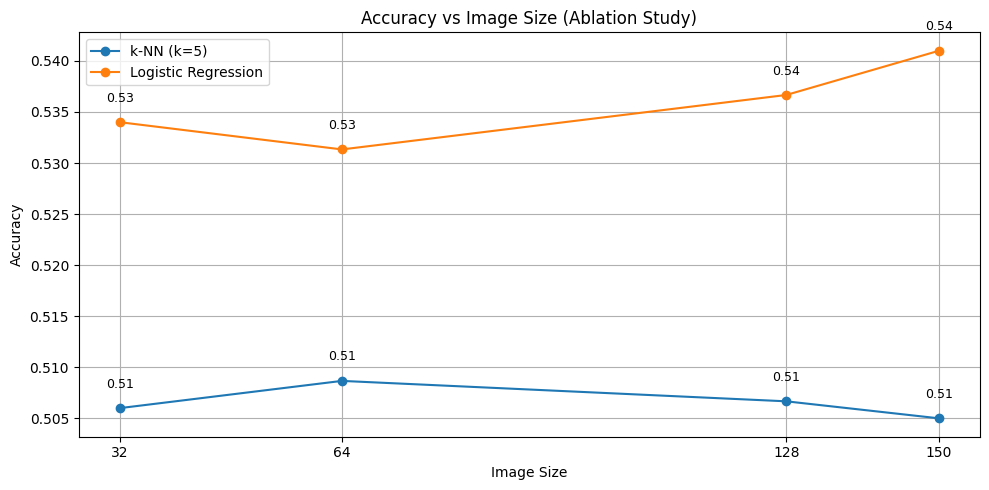

In [ ]:
#  MAIN
if not TRAIN_DIR.exists():
    print(f"  {TRAIN_DIR} không tồn tại.")
    exit()

print("[1/3] Load & ablation study ...")
df = ablation_study()

print("\n[2/3] Kết quả ...")
print_summary_table(df)

plot_accuracy_line(df)


### 1.5. Phân tích kết quả
<div align="justify">

**1. So sánh hiệu năng giữa các mô hình (Model Performance)**

Khác biệt rõ rệt: Logistic Regression (đường màu cam) luôn duy trì độ chính xác cao hơn k-NN (đường màu xanh) ở mọi mốc kích thước. Cụ thể, Logistic Regression dao động quanh mức 53.1% - 54.1%, trong khi k-NN chỉ đạt khoảng 50.5% - 50.9%.

Nguyên nhân: K-NN tính toán dựa trên khoảng cách hình học thuần túy giữa các vector. Trong không gian dữ liệu ảnh nhiều nhiễu, khoảng cách này thường kém hiệu quả. Ngược lại, Logistic Regression có khả năng học được các trọng số (weights) tối ưu cho từng thành phần đặc trưng, giúp phân tách các lớp cảnh quan tốt hơn.

**2. Tác động của Kích thước Ảnh (Image Size) đến Độ chính xác**

- Xu hướng đi ngang (Bão hòa thông tin): Trái với kỳ vọng thông thường rằng "ảnh càng lớn, độ chính xác càng cao", biểu đồ cho thấy cả hai mô hình gần như đi ngang. K-NN xuất phát ở mức 50.60% (size 32), nhích nhẹ lên đỉnh 50.9% (size 64) rồi lại lùi về 50.5% (size 150).

- Độ chính xác của Logistic Regression đạt đỉnh ở mốc 150x150 (~54.1%), trong khi ở mốc kích thước nhỏ nhất 32x32 mô hình vẫn đạt mức ~53.4%. Mức chênh lệch giữa ảnh rất mờ (32x32) và ảnh khá nét (150x150) chỉ là 0.7% – một sự đánh đổi rất nhỏ so với sự khác biệt khổng lồ về khối lượng pixel.

**3. Phân tích "Nút thắt cổ chai" (The PCA Bottleneck)**

Việc độ chính xác không tăng khi tăng kích thước ảnh có thể được giải thích qua cột pca_components. Dù ảnh đầu vào có số chiều cực lớn (67.500 chiều ở size 150) hay khá nhỏ (3.072 chiều ở size 32), tất cả đều bị thuật toán nén ép lại chỉ còn đúng 200 thành phần đặc trưng (components).

Điều này chứng tỏ 200 thành phần chính này đã đạt đến ngưỡng bão hòa trong việc trích xuất thông tin hữu ích cho hai mô hình tuyến tính/khoảng cách cơ bản này. Việc tăng độ nét của ảnh ban đầu không cung cấp thêm lượng thông tin mang tính phân loại nào lọt qua được "bộ lọc" PCA 200 chiều này.

**4. Chi phí Tính toán (Thời gian Huấn luyện)**

- k-NN có thời gian train_time_s gần như bằng 0 (~0.001s) do bản chất "lazy learning" (chỉ lưu trữ dữ liệu chứ không thực sự học trọng số ở pha train).

- Logistic Regression: Tốn nhiều thời gian hơn để tối ưu hóa trọng số (dao động từ 2.94s đến 4.86s). Đáng chú ý, thời gian train LR không tăng tuyến tính theo kích thước ảnh (size 32 tốn 4.23s trong khi size 64 chỉ tốn 2.94s). Lý do là vì đầu vào của LR lúc này luôn bị cố định ở mốc (13974 mẫu, 200 chiều), sự chênh lệch thời gian chỉ phụ thuộc vào tốc độ hội tụ của thuật toán tối ưu.

- Chi phí thực sự nằm ở PCA: Kích thước ảnh càng lớn, thời gian chạy PCA càng tăng phi mã (từ 7.7s cho size 32 lên tới 90.8s cho size 150). RAM tiêu thụ cũng tăng gấp hơn 20 lần (từ 172MB lên 3773MB).

**5. Kết luận & Biện luận lựa chọn**
Trong bối cảnh bài toán hiện tại (áp dụng PCA = 200), việc tăng kích thước ảnh lên 128x128 hoặc 150x150 là không cần thiết và lãng phí tài nguyên.

Kích thước 32x32 chính là lựa chọn tối ưu nhất xét trên góc độ đánh đổi Chi phí – Hiệu năng (Cost-Performance Trade-off). Dù mốc 150×150 cho độ chính xác cao nhất (54.1%), mốc 32x32 vẫn bám rất sát sao (53.4%) nhưng lại có số lượng đặc trưng gốc thấp nhất (chỉ 3.072 features so với 49.152 features của size 128 hay 67.500 features của size 150). Sự tinh gọn này giúp tối ưu hóa toàn diện tốc độ đọc/ghi, xử lý I/O, rút ngắn thời gian chạy PCA xuống chỉ còn ~7.7s và hạn chế tối đa nguy cơ tràn bộ nhớ RAM mà không làm suy giảm đáng kể hiệu suất phân loại.

### 1.6. Kết luận & Lựa chọn kích thước

| Size | k-NN Acc | LR Acc | RAM | PCA time |
|------|----------|--------|-----|----------|
| 32   | 0.51   | 0.53 | 172 MB  | 7.7s  |
| 64   | 0.51   | 0.53 | 687 MB  | 19.2s |
| 128  | 0.51   | 0.54 | 2747 MB | 69.0s |
| 150  | 0.51   | 0.54 | 3773 MB | 90.8s |

**Lựa chọn: `CHOSEN_SIZE = 32`**

LR đạt đỉnh ở 150x150 (~ 54%) nhưng chênh với 32x32 (~ 53%) chỉ **~0.1%** — không đáng kể thống kê. Ngược lại 32×32 giảm RAM 22× và PCA nhanh hơn 13×. Hiện tượng "PCA Bottleneck" (tất cả size đều bị nén về 200 components) giải thích tại sao tăng kích thước không mang lại thêm thông tin phân loại.

**→ `CHOSEN_SIZE = 32` kế thừa sang phần 2, c, d.**


In [ ]:
# ── Kết quả phần a → kế thừa sang b, c, d ──
CHOSEN_SIZE = 32
print(f"[1 → 2,3,4] CHOSEN_SIZE = {CHOSEN_SIZE}")


[1 → 2,3,4] CHOSEN_SIZE = 32


---
## 2. Chuyển đổi không gian màu <a id='2'></a>

> **Kế thừa từ phần 1:** `CHOSEN_SIZE = 32`


### 2.1. Lý thuyết và Kỹ thuật
<div align="justify">

Dữ liệu ảnh mặc định thường được lưu dưới dạng RGB (Red, Green, Blue). Tuy nhiên, trong không gian RGB, ba kênh màu có sự tương quan (correlation) rất cao và bị ảnh hưởng mạnh bởi cường độ ánh sáng chiếu vào vật thể. Việc chuyển sang các không gian màu khác giúp mô hình bóc tách được những thông tin bất biến (invariant features) hữu ích hơn cho bài toán phân loại cảnh quan tự nhiên.

*   RGB (Red, Green, Blue): Không gian màu phần cứng, dựa trên sự kết hợp ánh sáng. Không tối ưu cho trích xuất đặc trưng vì không tách biệt được độ sáng và màu sắc.

*   Grayscale (Ảnh xám): Loại bỏ hoàn toàn thông tin sắc độ, chỉ giữ lại cường độ sáng (luminance). Rất hữu ích khi hình khối, đường nét (edge) hoặc kết cấu (texture) quan trọng hơn màu sắc.

*   HSV (Hue, Saturation, Value): Không gian hình trụ. Hue (Màu sắc gốc - dải màu từ 0 đến 360 độ), Saturation (Độ bão hòa màu - độ rực rỡ), Value (Độ sáng). Đặc tính ưu việt là tách biệt hoàn toàn thành phần ánh sáng (V) khỏi màu sắc (H, S).

*   LAB (CIELAB): Được thiết kế để bám sát cảm nhận thị giác của mắt người (perceptually uniform). Bao gồm kênh $L$ (Lightness - Độ sáng), kênh $a$ (từ màu lục đến màu đỏ) và kênh $b$ (từ màu lam đến màu vàng).

### 2.2 Đo lường lượng thông tin bằng PCA (Principal Component Analysis)

Phân tích thành phần chính (PCA) là kỹ thuật giảm chiều dữ liệu bằng cách chiếu dữ liệu lên các trục trực giao (các vector riêng - eigenvectors) có phương sai lớn nhất.

Tỷ lệ phương sai giải thích (Explained Variance Ratio - EVR) của $k$ thành phần đầu tiên được tính bằng công thức:$$EVR_k = \frac{\sum_{i=1}^{k} \lambda_i}{\sum_{j=1}^{d} \lambda_j}$$
(Trong đó: $\lambda_i$ là trị riêng (eigenvalue) thứ $i$ tương ứng với phương sai của thành phần chính thứ $i$, và $d$ là tổng số chiều dữ liệu ban đầu).

Ý nghĩa: Phương sai (Variance) biểu diễn mức độ biến thiên (chứa đựng thông tin) của dữ liệu. Cùng nén xuống $k = 50$ thành phần, không gian màu nào có chỉ số Explained Variance cao hơn thì chứng tỏ không gian màu đó biểu diễn cấu trúc dữ liệu cốt lõi (core structures/patterns) cô đọng hơn, và PCA giữ lại được nhiều "thông tin hữu ích" của tập dữ liệu gốc hơn.


</div>


In [ ]:
# 0. CẤU HÌNH THAM SỐ
SIZE = CHOSEN_SIZE  # kế thừa phần 1
BATCH_SIZE = 500     # Số lượng ảnh nạp vào RAM mỗi lần
K_COMPONENTS = 50    # Số thành phần chính cần giữ lại (theo yêu cầu đề)

COLOR_SPACES = ['RGB', 'GRAY', 'HSV', 'LAB']


In [ ]:
def get_image_paths(data_dir):
    """Lấy danh sách tất cả đường dẫn ảnh trong tập Train"""
    paths = []
    for cls in CLASSES:
        cls_dir = data_dir / cls
        if cls_dir.exists():
            paths.extend(list(cls_dir.glob("*.jpg")) + list(cls_dir.glob("*.png")))
    return [str(p) for p in paths]

def color_space_generator(image_paths, color_space, batch_size=BATCH_SIZE):
    """
    Generator nạp từng batch ảnh, chuyển đổi không gian màu,
    resize và flatten thành vector 1D.
    """
    for i in range(0, len(image_paths), batch_size):
        batch_paths = image_paths[i : i + batch_size]
        X_batch = []

        for path in batch_paths:
            img = cv2.imread(path)
            if img is None: continue

            # Chuyển đổi không gian màu
            if color_space == 'RGB':
                img_conv = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            elif color_space == 'GRAY':
                img_conv = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            elif color_space == 'HSV':
                img_conv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
            elif color_space == 'LAB':
                img_conv = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)

            img_res = cv2.resize(img_conv, (SIZE, SIZE), interpolation=cv2.INTER_AREA)

            X_batch.append(img_res.flatten().astype(np.float32) / 255.0)

        yield np.array(X_batch)

def run_color_space_analysis():
    image_paths = get_image_paths(TRAIN_DIR)
    if not image_paths:
        print(f" Không tìm thấy ảnh tại: {TRAIN_DIR}")
        return

    print(f" Tổng số ảnh huấn luyện: {len(image_paths):,}")
    print(f" Kích thước phân tích: {SIZE}x{SIZE} | Số thành phần PCA k = {K_COMPONENTS}")
    print("_" * 60)

    results = []

    for space in COLOR_SPACES:
        print(f"\n Đang xử lý không gian màu: {space}")

        gen = color_space_generator(image_paths, space)
        X_all = np.concatenate(list(
            tqdm(gen,
                 total=(len(image_paths) + BATCH_SIZE - 1) // BATCH_SIZE,
                 desc=f"Load ({space})")
        ), axis=0)

        Xt   = torch.from_numpy(X_all).float().to(device)
        Xt   = Xt - Xt.mean(dim=0, keepdim=True)

        _, S, _ = torch.linalg.svd(Xt, full_matrices=False)
        S2   = (S ** 2)
        total_variance_explained = float((S2[:K_COMPONENTS].sum() / S2.sum()).cpu()) * 100
        del Xt, S, S2, X_all
        torch.cuda.empty_cache()

        results.append({
            "Color Space": space,
            "Explained Variance (k=50)": total_variance_explained
        })

        print(f" {space} - Phương sai giải thích được: {total_variance_explained:.2f}%")

    df_results = pd.DataFrame(results)
    df_results.sort_values(by="Explained Variance (k=50)", ascending=False, inplace=True)

    print("\n" + "_" * 50)
    print(" BẢNG TỔNG KẾT PHƯƠNG SAI GIẢI THÍCH THEO PCA")
    print("_" * 50)
    print(df_results.to_string(index=False, float_format="{:.2f}%".format))
    print("_" * 50)

if __name__ == "__main__":
    run_color_space_analysis()


 Tổng số ảnh huấn luyện: 13,974
 Kích thước phân tích: 32x32 | Số thành phần PCA k = 50
____________________________________________________________

 Đang xử lý không gian màu: RGB


Load (RGB): 100%|██████████| 28/28 [00:11<00:00,  2.36it/s]


 RGB - Phương sai giải thích được: 84.82%

 Đang xử lý không gian màu: GRAY


Load (GRAY): 100%|██████████| 28/28 [00:05<00:00,  5.05it/s]


 GRAY - Phương sai giải thích được: 85.82%

 Đang xử lý không gian màu: HSV


Load (HSV): 100%|██████████| 28/28 [00:08<00:00,  3.35it/s]


 HSV - Phương sai giải thích được: 81.68%

 Đang xử lý không gian màu: LAB


Load (LAB): 100%|██████████| 28/28 [00:09<00:00,  3.08it/s]


 LAB - Phương sai giải thích được: 83.97%

__________________________________________________
 BẢNG TỔNG KẾT PHƯƠNG SAI GIẢI THÍCH THEO PCA
__________________________________________________
Color Space  Explained Variance (k=50)
       GRAY                     85.82%
        RGB                     84.82%
        LAB                     83.97%
        HSV                     81.68%
__________________________________________________


### 2.3. Phân tích kết quả PCA Explained Variance
<div align="justify">

**1. Sự vươn lên dẫn đầu của hệ màu ảnh xám (Grayscale - 85.82%)**

Khác với trực giác thông thường rằng ảnh màu sẽ chứa nhiều thông tin hơn, kết quả thực nghiệm lại cho thấy không gian ảnh xám (GRAY) dẫn đầu với 85.82% lượng thông tin (phương sai) được bảo toàn chỉ với 50 thành phần PCA.

Nguyên nhân: Đối với tập dữ liệu cảnh quan tự nhiên và kiến trúc (Intel Image Classification), cấu trúc không gian hình học (như đường viền của tòa nhà, nếp gấp của núi, ranh giới giữa biển và trời) đóng vai trò định hình cốt lõi. Việc chuyển sang Grayscale làm mất đi nhiễu sắc độ (color noise) nhưng lại "cô đặc" sự biến thiên của hình khối và độ tương phản sáng tối vào một ma trận duy nhất. Do PCA không bị phân tán tài nguyên để cố gắng nén các kênh màu độc lập, 50 thành phần chính thu được trọn vẹn những cấu trúc cốt lõi nhất của bức ảnh. Hơn nữa, vì dữ liệu đầu vào giảm 3 lần (1 kênh thay vì 3 kênh), thời gian chạy PCA cho GRAY cũng nhanh gấp đôi RGB (6 giây so với 12 giây).

**2. Hiệu suất bám đuổi sát sao của hệ màu RGB (84.82%)**

Dù phải nén dữ liệu từ một không gian rộng hơn gấp 3 lần (3 kênh Red, Green, Blue), hệ màu RGB vẫn giữ được hiệu suất cực kỳ ấn tượng ở mức 84.82%, chỉ thua GRAY đúng 1%.

Nguyên nhân: Trong ảnh cảnh quan tự nhiên, có sự liên kết cấu trúc cục bộ và tương quan (correlation) cực kỳ chặt chẽ giữa 3 kênh RGB. Ví dụ: Rừng (forest) sẽ có cường độ Green đi liền với dải màu đất; Biển (sea) và Trời luôn có sự đồng biến mạnh ở kênh Blue. Thuật toán PCA hoạt động dựa trên ma trận hiệp phương sai tuyến tính. Chính sự tương quan tuyến tính rất lớn giữa 3 kênh màu tự nhiên này đã tạo ra những "trục biến thiên chính" (principal components) cực kỳ rõ ràng, giúp PCA dễ dàng tóm gọn gần 85% thông tin vào 50 vector đầu tiên.

**3. Sự giới hạn của các hệ màu phân tách sáng-tối (LAB và HSV)**

Mặc dù mang ý nghĩa vật lý mạnh mẽ, không gian LAB chỉ đạt 83.97% và HSV xếp cuối cùng với 81.68%.

Nguyên nhân: Dù HSV và LAB được thiết kế tinh vi để cô lập cường độ ánh sáng (Value/Lightness) khỏi màu sắc gốc (Hue/ab), bản chất của việc phân tách này lại tạo ra các kênh dữ liệu có độ biến thiên độc lập cao, ít tương quan tuyến tính với nhau hơn so với RGB.
PCA là một thuật toán biến đổi tuyến tính, do đó nó gặp "khớp gãy" khi xử lý các dữ liệu phi tuyến. Đặc biệt rõ rệt nhất ở không gian HSV: kênh Hue (Sắc độ) là một dải tuần hoàn (vòng tròn góc 360 độ, trong đó 0 độ và 360 độ đều là màu đỏ). Việc ép một đại lượng hình học góc (tuần hoàn) vào các phép tính phương sai đại số tuyến tính của PCA đã làm sai lệch và thất thoát đi một phần lượng thông tin nguyên bản.

**4. Đột phá về Tỷ lệ phương sai (Giải thích hiện tượng EVR nhảy vọt lên >80%)**

Nếu so với khi chạy PCA trên kích thước gốc 150x150 (chỉ đạt quanh mức 68%) ở ngoài nội dung bài nộp, ở kích thước 32x32 này, tỷ lệ phương sai giải thích đã nhảy vọt lên dải 81% - 85% dù vẫn chỉ dùng k=50.

Nguyên nhân: Kích thước 32x32 làm giảm mạnh "tổng số chiều" của dữ liệu ban đầu (từ 67.500 chiều xuống chỉ còn 3.072 chiều đối với RGB, và từ 22.500 xuống vỏn vẹn 1.024 chiều đối với GRAY). Khi không gian mẫu (feature space) bị thu hẹp đi hàng chục lần, 50 thành phần chính (components) dễ dàng "bao phủ" và thâu tóm được một tỷ lệ thông tin lớn hơn rất nhiều so với khi chúng phải hoạt động trong không gian khổng lồ của ảnh 150x150.

**5. Thảo luận: Không gian màu nào bảo toàn thông tin tốt nhất?**

Ở mốc kích thước nén 32x32, Grayscale chính là không gian tối ưu nhất cả về mặt toán học lẫn tài nguyên phần cứng. Nó không chỉ đạt tỷ lệ bảo toàn phương sai cao nhất (85.82%) mà còn tiết kiệm 66% lượng RAM tiêu thụ và giảm 50% thời gian tính toán so với RGB.

### 2.4. Ablation Study cho Không gian màu (Color Space)
<div align="justify">

*  Giữ nguyên ảnh gốc (150x150): Hàm load dữ liệu ban đầu sẽ đọc toàn bộ ảnh vào RAM dưới định dạng RGB uint8 ở kích thước 150x150.

*  Hàm convert_to_flat: Hàm này sẽ nhận mảng RGB gốc, dùng OpenCV chuyển sang GRAY, HSV, hoặc LAB, sau đó flatten và chia 255.0.

*  Giảm chiều dữ liệu PCA (k=50):thiết lập cố định số thành phần N_PCA_COMP = 50.

*  Vẽ biểu đồ Bar Chart

In [ ]:
#  CẤU HÌNH THAM SỐ
COLOR_SPACES = ['RGB', 'GRAY', 'HSV', 'LAB']
SIZE         = CHOSEN_SIZE  # kế thừa phần 1
N_PCA_COMP   = 50   # Số thành phần PCA cố định theo đề bài

KNN_K        = 5
LR_MAX_ITER  = 1000
N_WORKERS    = min(8, os.cpu_count() or 4)

PALETTE = {f"k-NN (k={KNN_K})": "#4361EE", "Logistic Regression": "#F72585"}


[1/3] Tiến hành Ablation Study trên Không gian màu...
  Load train (RGB uint8) ...


   uint8 array: (13974, 32, 32, 3)  RAM≈43MB
  Load test (RGB uint8) ...


   uint8 array: (3000, 32, 32, 3)  RAM≈9MB

_______________________________________________________
  [KHÔNG GIAN MÀU: RGB]
_______________________________________________________
  Converting to RGB & Flattening ...   Shape: (13974, 3072)  RAM≈172MB
  Running PCA (k=50)...
      [PCA-GPU Elapsed] 5.3s | Explained Var: 84.82%
  k-NN   Acc=0.53  train=0.0s
  LR     Acc=0.55  train=1.5s

_______________________________________________________
  [KHÔNG GIAN MÀU: GRAY]
_______________________________________________________
  Converting to GRAY & Flattening ...   Shape: (13974, 1024)  RAM≈57MB
  Running PCA (k=50)...
      [PCA-GPU Elapsed] 0.3s | Explained Var: 85.82%
  k-NN   Acc=0.45  train=0.0s
  LR     Acc=0.43  train=1.3s

_______________________________________________________
  [KHÔNG GIAN MÀU: HSV]
_______________________________________________________
  Converting to HSV & Flattening ...   Shape: (13974, 3072)  RAM≈172MB
  Running PCA (k=50)...
      [PCA-GPU Elapsed] 5.5s | Exp

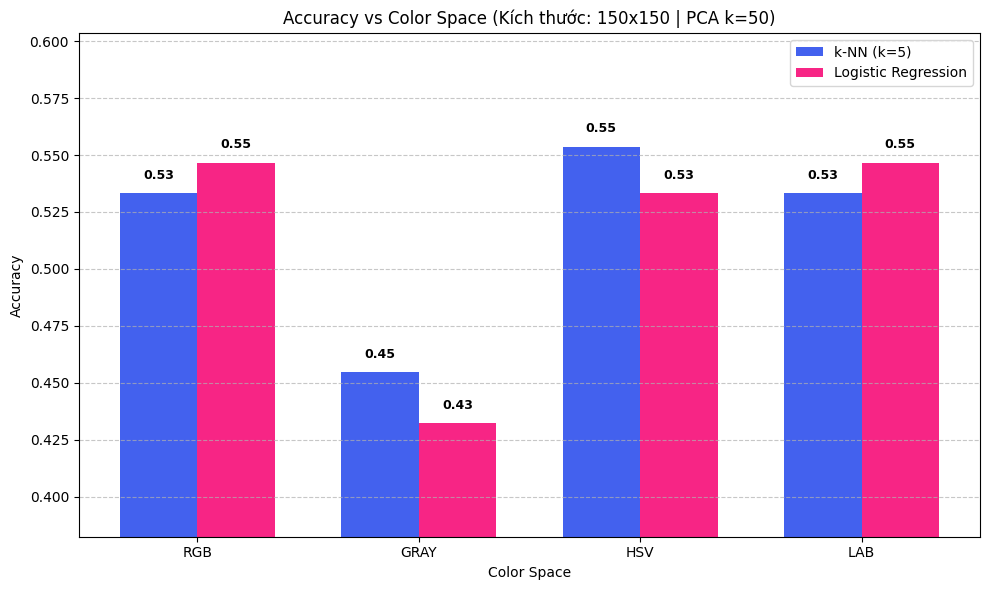

In [ ]:

def _read_one(args):
    path, label = args
    img = cv2.imread(path)
    if img is None:
        return None, label, path
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (SIZE, SIZE), interpolation=cv2.INTER_AREA)
    return img, label, path

def load_uint8(data_dir: Path):
    tasks = []
    for cls in CLASSES:
        cls_dir = data_dir / cls
        if not cls_dir.exists(): continue
        for fp in sorted(cls_dir.glob("*.jpg")) + sorted(cls_dir.glob("*.png")):
            tasks.append((str(fp), CLASS_LABELS[cls]))

    # Keep deterministic sample order independent of thread completion timing.
    rows = []
    with ThreadPoolExecutor(max_workers=N_WORKERS) as exe:
        futures = {exe.submit(_read_one, t): t for t in tasks}
        for fut in tqdm(as_completed(futures), total=len(tasks),
                        desc=f"   read {data_dir.parent.name}", leave=False):
            img, lbl, path = fut.result()
            if img is not None:
                rows.append((path, lbl, img))

    rows.sort(key=lambda x: x[0])
    imgs = [r[2] for r in rows]
    labels = [r[1] for r in rows]

    X = np.stack(imgs, axis=0)  # (N, 150, 150, 3) uint8
    y = np.array(labels, dtype=np.int32)
    print(f"   uint8 array: {X.shape}  RAM≈{X.nbytes/1e6:.0f}MB")
    return X, y

def convert_to_flat(X_rgb_uint8: np.ndarray, color_space: str) -> np.ndarray:
    """Chuyển RGB sang không gian màu mong muốn và flatten thành float32 [0, 1]"""
    N = len(X_rgb_uint8)
    channels = 1 if color_space == 'GRAY' else 3
    out = np.empty((N, SIZE * SIZE * channels), dtype=np.float32)

    for i in range(N):
        img = X_rgb_uint8[i]

        if color_space == 'RGB':
            conv = img
        elif color_space == 'GRAY':
            conv = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        elif color_space == 'HSV':
            conv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
        elif color_space == 'LAB':
            conv = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)

        out[i] = conv.flatten().astype(np.float32) / 255.0

    return out

#  TIỀN XỬ LÝ: PCA (k=50)
def preprocess_pca(X_train, X_test):
    """SVD trên GPU (T4) — nhanh hơn sklearn randomized ~5-10x."""
    t0   = time.time()
    Xtr  = torch.from_numpy(X_train).float().to(device)
    mean = Xtr.mean(dim=0, keepdim=True)
    Xtr  = Xtr - mean
    _, S, Vh = torch.linalg.svd(Xtr, full_matrices=False)
    V    = Vh[:N_PCA_COMP].T                              # (D, k)
    Xtr_pca = (Xtr @ V).cpu().numpy()

    Xte  = torch.from_numpy(X_test).float().to(device) - mean
    Xte_pca = (Xte @ V).cpu().numpy()

    # Tính explained variance từ singular values
    S2  = (S ** 2)
    var = float((S2[:N_PCA_COMP].sum() / S2.sum()).cpu()) * 100
    del Xtr, Xte, S, Vh, V, S2, mean
    torch.cuda.empty_cache()

    print(f"      [PCA-GPU Elapsed] {time.time()-t0:.1f}s | Explained Var: {var:.2f}%")
    return Xtr_pca, Xte_pca

#  ĐÁNH GIÁ MÔ HÌNH
def evaluate_model(model, X_tr, y_tr, X_te, y_te, name):
    t0 = time.time(); model.fit(X_tr, y_tr); tt = time.time()-t0
    t0 = time.time(); yp = model.predict(X_te); ti = time.time()-t0
    return dict(model_name=name, accuracy=accuracy_score(y_te, yp),
                train_time=tt, infer_time=ti)

#  ABLATION LOOP: SO SÁNH KHÔNG GIAN MÀU
def run_color_ablation():
    records = []

    print("  Load train (RGB uint8) ...")
    X_tr_raw, y_tr = load_uint8(TRAIN_DIR)
    print("  Load test (RGB uint8) ...")
    X_te_raw, y_te = load_uint8(TEST_DIR)

    for space in COLOR_SPACES:
        print(f"\n{'_'*55}\n  [KHÔNG GIAN MÀU: {space}]\n{'_'*55}")

        print(f"  Converting to {space} & Flattening ...", end=" ", flush=True)
        X_tr_flat = convert_to_flat(X_tr_raw, space)
        X_te_flat = convert_to_flat(X_te_raw, space)
        feat_dim  = X_tr_flat.shape[1]
        print(f"  Shape: {X_tr_flat.shape}  RAM≈{X_tr_flat.nbytes/1e6:.0f}MB")

        print(f"  Running PCA (k={N_PCA_COMP})...")
        X_tr, X_te = preprocess_pca(X_tr_flat, X_te_flat)

        # Dọn dẹp NGAY mảng flat khổng lồ sau khi PCA xong
        del X_tr_flat, X_te_flat; gc.collect()

        # --- k-NN ---
        knn = KNeighborsClassifier(KNN_K, metric="euclidean", n_jobs=-1)
        rk  = evaluate_model(knn, X_tr, y_tr, X_te, y_te, f"k-NN (k={KNN_K})")
        print(f"  k-NN   Acc={rk['accuracy']:.2f}  train={rk['train_time']:.1f}s")

        # --- Logistic Regression ---
        lr  = LogisticRegression(max_iter=LR_MAX_ITER, solver="lbfgs",
                                 multi_class="multinomial",
                                 random_state=SEED, n_jobs=-1)
        rl  = evaluate_model(lr,  X_tr, y_tr, X_te, y_te, "Logistic Regression")
        print(f"  LR     Acc={rl['accuracy']:.2f}  train={rl['train_time']:.1f}s")

        for r in [rk, rl]:
            records.append(dict(color_space=space, model=r["model_name"],
                                feature_dim=feat_dim, pca_components=N_PCA_COMP,
                                accuracy=r["accuracy"], train_time_s=r["train_time"],
                                infer_time_s=r["infer_time"]))

        # Xoá PCA output trước khi chạy Color Space tiếp theo
        del X_tr, X_te; gc.collect()

    # Giải phóng hoàn toàn dữ liệu thô
    del X_tr_raw, X_te_raw; gc.collect()
    return pd.DataFrame(records)

#  VISUALIZATION
def print_summary_table(df):
    print("\n"+"_"*75)
    print("  BẢNG KẾT QUẢ ABLATION STUDY – KHÔNG GIAN MÀU (PCA k=50)")
    print("_"*75)
    print(df[["color_space","model","feature_dim","pca_components",
              "accuracy","train_time_s"]].to_string(index=False, float_format="{:.2f}".format))
    print("_"*75)

def plot_accuracy_bar(df, save="acc_color_space_chart.png"):
    plt.figure(figsize=(10, 6))

    spaces = df["color_space"].unique()
    models = df["model"].unique()

    x = np.arange(len(spaces))
    width = 0.35

    # Vẽ cột cho từng model
    for i, model in enumerate(models):
        subset = df[df["model"] == model]
        # Sắp xếp đúng thứ tự các không gian màu
        accs = [subset[subset["color_space"] == sp]["accuracy"].values[0] for sp in spaces]

        offset = (i - 0.5) * width
        bars = plt.bar(x + offset, accs, width, label=model, color=PALETTE.get(model, 'gray'))

        # Thêm text giá trị lên đầu mỗi cột
        for bar, acc in zip(bars, accs):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                     f'{acc:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    plt.xlabel("Color Space")
    plt.ylabel("Accuracy")
    plt.title(f"Accuracy vs Color Space (Kích thước: 150x150 | PCA k={N_PCA_COMP})")
    plt.xticks(x, spaces)

    # Điều chỉnh trục Y để đồ thị nhìn thoáng hơn
    min_acc = df["accuracy"].min()
    max_acc = df["accuracy"].max()
    plt.ylim(min_acc - 0.05, max_acc + 0.05)

    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.show()

#  MAIN
def main():
    if not TRAIN_DIR.exists():
        print(f"  {TRAIN_DIR} không tồn tại."); return

    print("[1/3] Tiến hành Ablation Study trên Không gian màu...")
    df = run_color_ablation()

    print("\n[2/3] Kết quả phân loại...")
    print_summary_table(df)

    print("\n[3/3] Trực quan hóa dữ liệu...")
    plot_accuracy_bar(df)

if __name__ == "__main__":
    main()


### 2.5. Phân tích kết quả Ablation Study cho Không gian màu (Color Space)
<div align="justify">

**1. Sự sụp đổ của ảnh Xám (GRAY)**

Hiện tượng: Khi chuyển từ RGB sang GRAY, độ chính xác của cả hai mô hình sụt giảm nghiêm trọng. Cụ thể, k-NN giảm từ 53% xuống 45%, và Logistic Regression giảm mạnh từ 55% xuống 43% (mức thấp nhất trong toàn bộ thực nghiệm).

Giải thích : Bộ dữ liệu Intel Image Classification chứa các cảnh quan tự nhiên (rừng, biển, sông băng...). Trong tự nhiên, màu sắc là một đặc trưng định danh (discriminative feature) cực kỳ mạnh mẽ. Một mảng pixel màu xanh lục gần như chắc chắn là rừng, màu xanh lam là biển. Khi dập tắt thông tin màu sắc và chỉ giữ lại cường độ sáng trong ảnh GRAY, một ngọn núi đá xám (mountain) và một khu rừng rậm (forest) có thể mang lại những cấu trúc vân bề mặt (texture) rất giống nhau sau khi bị ép nén qua PCA. Sự sụt giảm ~10% độ chính xác minh chứng rằng: đối với bài toán phân loại cảnh quan, hình khối (shape) là chưa đủ, màu sắc là nhân tố không thể lược bỏ.

**2. Sức mạnh của việc Phân tách Ánh sáng và Sắc độ (HSV và LAB)**

Hiện tượng: Cả HSV và LAB đều mang lại hiệu suất ngang bằng hoặc nhỉnh hơn RGB tùy thuộc vào thuật toán. HSV đạt đỉnh cao nhất ở mô hình k-NN (55%), trong khi LAB đạt đỉnh ở mô hình Logistic Regression (55%). Về thời gian huấn luyện, ngoại trừ mô hình LR trên HSV tốn thời gian hội tụ lâu hơn một chút (2.04s), các không gian màu khác đều duy trì tốc độ train LR rất nhanh (khoảng 1.26s - 1.49s).

Giải thích bản chất: Trong không gian RGB, ba kênh màu hòa quyện vào nhau. Một bức ảnh chụp rừng lúc nắng gắt và lúc chiều tối sẽ có các vector RGB sai lệch nhau cực lớn, khiến mô hình dễ bị bối rối. Ngược lại, HSV và LAB cô lập cường độ ánh sáng (kênh V trong HSV, kênh L trong LAB) khỏi màu sắc gốc. Việc này giúp các thuật toán "nhìn xuyên" qua điều kiện thời tiết/ánh sáng để nhận diện các bức ảnh có chung màu sắc đặc trưng. Hệ quả là không gian vector trở nên ít rối rắm (decorrelated) hơn, giúp phân tách các lớp dữ liệu hiệu quả hơn.

**3. Sự khác biệt hành vi giữa k-NN và Logistic Regression**

k-NN "ưa thích" HSV: k-NN phân loại dựa trên khoảng cách hình học. Không gian HSV biểu diễn sắc độ (Hue) theo dạng góc, tạo ra các cụm màu rất chặt chẽ (ví dụ: tất cả màu xanh của biển sẽ nằm chung một góc tọa độ H). Khoảng cách trên các thành phần PCA của HSV tỏ ra đáng tin cậy hơn để thuật toán k-NN tìm ra các "hàng xóm" tương đồng.

Logistic Regression "ưa thích" LAB: LAB là không gian màu đồng nhất về mặt tri giác (perceptually uniform) và có tính đại số tuyến tính cao hơn HSV. Logistic Regression hoạt động dựa trên việc đi tìm các mặt phẳng siêu tuyến tính để chia tách dữ liệu. Sự phân bổ tuyến tính của các trục màu đối lập ($a^*$ và $b^*$) trong LAB hỗ trợ cực tốt cho việc tối ưu hàm mất mát của LR, giúp mô hình đạt đỉnh 55%.

**4. Nghịch lý của PCA: "Nhiều thông tin" chưa chắc đã "Phân loại tốt"**

Đối chiếu với phép đo lường phương sai giải thích (Explained Variance Ratio - EVR) từ bước trước, ta thấy một nghịch lý cực kỳ thú vị và rõ nét:
- Ảnh GRAY giữ lại nhiều thông tin nguyên bản nhất (85.82%) nhưng lại cho kết quả phân loại tệ nhất.
- Không gian HSV mất nhiều phương sai nhất (chỉ giữ được 81.68% với $k=50$) nhưng lại mang về độ chính xác cao nhất cho k-NN (0.55).
- Ý nghĩa sâu sắc: Phương sai (Variance) mà PCA cố gắng giữ lại đơn thuần chỉ là "sự biến thiên của dữ liệu", nó hoàn toàn có thể là nhiễu ánh sáng (bóng râm, mây, cường độ sáng rực rỡ). Khi PCA xử lý ảnh GRAY hoặc RGB, nó ưu tiên giữ lại các biến thiên ánh sáng vô bổ này và bỏ lỡ các thông tin màu sắc quan trọng. Ngược lại, vì HSV đã bóc tách ánh sáng, dù 50 vector PCA của nó mang tổng mức biến thiên nhỏ hơn (81.68%), nhưng đó lại là lượng thông tin "sạch" và thuần túy về sắc độ, trực tiếp phục vụ cho việc định danh nhãn lớp.

**Kết luận & Đề xuất:**

Qua thực nghiệm Ablation, việc sử dụng ảnh xám (GRAY) cho bài toán này là một bước lùi. Các không gian màu phân tách ánh sáng như LAB (kết hợp với Logistic Regression) hoặc HSV (kết hợp k-NN) là những lựa chọn tối ưu. Dù không thay đổi thời gian huấn luyện, chúng giúp không gian vector được tinh gọn, loại bỏ nhiễu ánh sáng và bứt phá giới hạn Accuracy của không gian RGB nguyên bản.

### 2.6. Kết luận & Lựa chọn không gian màu

| Color Space | k-NN Acc | LR Acc | Explained Var (k=50) | LR Time |
|-------------|----------|--------|----------------------|---------|
| RGB  | 0.53 | 0.55 | 84.82% | 1.49s |
| GRAY | 0.45 | 0.43 | 85.82% | 1.26s |
| HSV  | 0.55 | 0.53 | 83.97% | 2.04s |
| LAB  | 0.53| 0.55 | 81.68% | 1.36s |

**Lựa chọn: `CHOSEN_COLOR_SPACE = 'HSV'`**

HSV cho k-NN cao nhất (~ 55%) và duy trì mức ổn định với Logistic Regression. GRAY bị loại vì mất ~10% accuracy (màu sắc là đặc trưng định danh chính của cảnh quan). HSV tách ánh sáng khỏi sắc độ giúp mô hình bất biến với điều kiện chiếu sáng. Z-score Per-channel (phần 3) sẽ chuẩn hóa độc lập 3 kênh H/S/V — quan trọng vì H/S/V có đơn vị hoàn toàn khác nhau.


In [ ]:
CHOSEN_COLOR_SPACE = 'HSV'
print(f"[2 → 3,4] CHOSEN_COLOR_SPACE = {CHOSEN_COLOR_SPACE!r}")
print(f"  Pipeline đến đây: SIZE={CHOSEN_SIZE} | COLOR={CHOSEN_COLOR_SPACE}")


[2 → 3,4] CHOSEN_COLOR_SPACE = 'HSV'
  Pipeline đến đây: SIZE=32 | COLOR=HSV


---
## 3. Chuẩn hóa pixel (Normalization) <a id='3'></a>


### 3.0. Load ảnh với tham số kế thừa

Load ảnh ở `32×32` (phần 1), chuyển sang `HSV` (phần 2) on-the-fly trong DataLoader.


In [ ]:
IMG_SIZE   = CHOSEN_SIZE  # Lấy size 32
BATCH_SIZE = 1024

class IntelDataset(Dataset):
    def __init__(self, paths, size=IMG_SIZE):
        self.paths = paths
        self.size  = size
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, idx):
        img = cv2.imread(self.paths[idx])
        if img is None:
            return torch.zeros(3, self.size, self.size, dtype=torch.uint8)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (self.size, self.size))
        # Chuyển không gian màu
        if CHOSEN_COLOR_SPACE == 'HSV':
            img = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
        elif CHOSEN_COLOR_SPACE == 'LAB':
            img = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
        elif CHOSEN_COLOR_SPACE == 'GRAY':
            gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
            img  = np.stack([gray]*3, axis=-1)
        return torch.from_numpy(img).permute(2, 0, 1)

dataset = IntelDataset(image_paths)
def seed_worker(worker_id):
    np.random.seed(SEED + worker_id)
    random.seed(SEED + worker_id)

g = torch.Generator()
g.manual_seed(SEED)

loader  = DataLoader(dataset, batch_size=BATCH_SIZE,
                     num_workers=os.cpu_count(), pin_memory=True,
                     prefetch_factor=2, persistent_workers=True,
                     worker_init_fn=seed_worker, generator=g)

print(f"Bắt đầu load {N_TOTAL} ảnh (batch={BATCH_SIZE}, workers={os.cpu_count()})...")

all_imgs = []
with torch.no_grad():
    for batch in tqdm(loader, desc="Đọc toàn bộ ảnh"):
        all_imgs.append(batch.numpy())

X_chw  = np.concatenate(all_imgs, axis=0)               # (N, 3, 64, 64)  uint8
X_hwc  = X_chw.transpose(0, 2, 3, 1)                    # (N, 64, 64, 3)  uint8
X_flat = X_chw.reshape(N_TOTAL, -1).astype(np.float32)  # (N, 12288)      float32
print(f"X_flat shape : {X_flat.shape}  dtype={X_flat.dtype}")
print(f"RAM ước tính : {X_flat.nbytes / 1e9:.2f} GB")


Bắt đầu load 13974 ảnh (batch=1024, workers=2)...


Đọc toàn bộ ảnh: 100%|██████████| 14/14 [00:04<00:00,  3.44it/s]

X_flat shape : (13974, 3072)  dtype=float32
RAM ước tính : 0.17 GB


### 3.0.1. Tính thống kê toàn tập trên GPU

Các tham số $x_{\min}$, $x_{\max}$, $\mu$, $\sigma$ cần được tính **một lần duy nhất** trên toàn bộ tập Train trước khi chuẩn hóa. Điều này đảm bảo rằng khi áp dụng lên tập Test sau này, ta dùng đúng các hằng số từ Train — tránh data leakage.

Ta đưa toàn bộ tensor lên GPU để tận dụng phép tính song song trên VRAM, sau đó giải phóng ngay.

In [ ]:
X_tensor = torch.from_numpy(X_chw).float().to(device)

global_min  = float(X_tensor.min())
global_max  = float(X_tensor.max())
global_mean = float(X_tensor.mean())
global_std  = float(X_tensor.std())

channel_mean = X_tensor.mean(dim=[0, 2, 3]).cpu().numpy()
channel_std  = X_tensor.std(dim=[0, 2, 3]).cpu().numpy()

del X_tensor
torch.cuda.empty_cache()

print("Thống kê toàn tập:")
print(f"  global_min  = {global_min:.2f}")
print(f"  global_max  = {global_max:.2f}")
print(f"  global_mean = {global_mean:.4f}")
print(f"  global_std  = {global_std:.4f}")
print(f"\n  Per-channel mean (R, G, B) = {channel_mean.round(2)}")
print(f"  Per-channel std  (R, G, B) = {channel_std.round(2)}")


Thống kê toàn tập:
  global_min  = 0.00
  global_max  = 255.00
  global_mean = 90.5773
  global_std  = 66.9572

  Per-channel mean (R, G, B) = [ 66.65  74.78 130.3 ]
  Per-channel std  (R, G, B) = [46.23 64.08 69.33]


### 3.1. Lý thuyết và Công thức

Chuẩn hóa là phép biến đổi tuyến tính đưa miền giá trị pixel từ $[0, 255]$ sang một miền nhỏ hơn. Mục đích chính có hai khía cạnh:

Thứ nhất, giúp ổn định gradient descent khi huấn luyện mạng nơ-ron — nếu đầu vào có miền $[0, 255]$, trọng số lớp đầu tiên phải được khởi tạo rất nhỏ để gradient không bùng nổ, trong khi đầu vào về $[-1, 1]$ hay $[0, 1]$ giúp chọn learning rate và khởi tạo trọng số dễ hơn nhiều.

Thứ hai, với các thuật toán dựa trên khoảng cách như k-NN hay SVM, nếu một đặc trưng có miền $[0, 255]$ trong khi đặc trưng khác có miền $[0, 1]$, đặc trưng đầu sẽ chi phối hoàn toàn khoảng cách Euclidean, khiến đặc trưng sau không có đóng góp thực tế.

Ta so sánh bốn phương pháp:

**Phương pháp 1 — Min-Max $[0, 1]$:**

$$x' = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$$

Co dãn tuyến tính toàn bộ miền về $[0, 1]$. Vì ảnh số 8-bit luôn có $x_{\min} = 0$ và $x_{\max} = 255$, công thức đơn giản thành $x' = x / 255$.

**Phương pháp 2 — Min-Max $[-1, 1]$:**

$$x' = \frac{2(x - x_{\min})}{x_{\max} - x_{\min}} - 1$$

Tương tự phương pháp 1 nhưng dịch miền về $[-1, 1]$. Hữu ích khi dùng activation function đối xứng như $\tanh$.

**Phương pháp 3 — Z-score toàn tập:**

$$x' = \frac{x - \mu}{\sigma}$$

Trong đó $\mu$ và $\sigma$ tính trên **toàn bộ pixel của toàn bộ ảnh** không phân biệt kênh. Kết quả có $\mu' = 0$ và $\sigma' = 1$.

**Phương pháp 4 — Z-score Per-channel:**

$$x'_c = \frac{x_c - \mu_c}{\sigma_c}, \quad c \in \{R, G, B\}$$

Chuẩn hóa riêng từng kênh màu bằng $\mu_c$ và $\sigma_c$ của kênh đó. Mỗi kênh đều có $\mu'_c = 0$ và $\sigma'_c = 1$, triệt tiêu hoàn toàn hiện tượng thiên lệch màu (color bias). Đây là chuẩn mực được dùng trong ImageNet pre-training với $\mu = [0.485, 0.456, 0.406]$ và $\sigma = [0.229, 0.224, 0.225]$.

Từ kết quả EDA ở notebook trước, kênh Green có $\mu_G = 116.56$ cao hơn Red ($\mu_R = 109.63$) và Blue ($\mu_B = 115.69$) — tập dữ liệu này có color bias nghiêng về xanh lá do nhiều cảnh rừng và núi. Z-score Per-channel sẽ triệt tiêu bias này.

In [ ]:
X_t = torch.from_numpy(X_chw).float().to(device)          # (N, 3, H, W)

X_mm01 = ((X_t - global_min) / (global_max - global_min)).cpu().numpy().reshape(N_TOTAL, -1)
X_mm11 = (2.0 * (X_t - global_min) / (global_max - global_min) - 1.0).cpu().numpy().reshape(N_TOTAL, -1)
X_zg   = ((X_t - global_mean) / global_std).cpu().numpy().reshape(N_TOTAL, -1)

# Z-score per-channel
ch_mean_t = torch.tensor(channel_mean, device=device).view(1, 3, 1, 1)
ch_std_t  = torch.tensor(channel_std,  device=device).view(1, 3, 1, 1)
X_zpc     = ((X_t - ch_mean_t) / ch_std_t).cpu().numpy().reshape(N_TOTAL, -1)

del X_t, ch_mean_t, ch_std_t
torch.cuda.empty_cache()

norm_dict = {
    'Gốc [0,255]'         : X_flat,
    'Min-Max [0,1]'       : X_mm01,
    'Min-Max [-1,1]'      : X_mm11,
    'Z-score Global'      : X_zg,
    'Z-score Per-channel' : X_zpc,
}

print(f"{'Phương pháp':<25s} {'min':>8s} {'max':>8s} {'mean':>10s} {'std':>10s}")
print("_" * 65)
for name, arr in norm_dict.items():
    print(f"{name:<25s} {arr.min():>8.2f} {arr.max():>8.2f} {arr.mean():>10.2f} {arr.std():>10.2f}")


Phương pháp                    min      max       mean        std
_________________________________________________________________
Gốc [0,255]                   0.00   255.00      90.58      66.96
Min-Max [0,1]                 0.00     1.00       0.36       0.26
Min-Max [-1,1]               -1.00     1.00      -0.29       0.53
Z-score Global               -1.35     2.46       0.00       1.00
Z-score Per-channel          -1.88     2.81      -0.00       1.00


### 3.2. Kiểm định Kolmogorov-Smirnov (KS Test)

Sau khi chuẩn hóa, ta đánh giá định lượng xem phân phối pixel **thực sự thay đổi** hay chỉ thay đổi về scale. Kiểm định Kolmogorov-Smirnov hai mẫu là công cụ phù hợp cho mục đích này.

**Nguyên lý:** Cho hai mẫu $X$ và $Y$ với hàm phân phối tích lũy thực nghiệm lần lượt là $F_X(t)$ và $F_Y(t)$. Thống kê KS được định nghĩa là:

$$D = \sup_t |F_X(t) - F_Y(t)|$$

$D$ đo khoảng cách lớn nhất giữa hai đường CDF. Giá trị $D$ lớn đồng nghĩa hai phân phối khác nhau nhiều.

$H_0$: Hai mẫu được rút ra từ cùng một phân phối.

$H_1$: Hai mẫu đến từ hai phân phối khác nhau.

Nếu $p\text{-value} < 0.05$, ta bác bỏ $H_0$.

**Lưu ý:** Với dữ liệu cỡ lớn ($n > 10^5$), KS test có độ nhạy rất cao — kể cả sai khác rất nhỏ cũng cho $p \approx 0$. Do đó ngoài $p\text{-value}$, ta cần chú trọng giá trị $D$ để đánh giá mức độ thực tế của sự khác biệt.

In [ ]:
N_KS = 100_000
rng  = np.random.RandomState(SEED)

raw_flat   = X_flat.flatten()
idx_raw    = rng.choice(len(raw_flat), size=N_KS, replace=False)
raw_sample = raw_flat[idx_raw]

ks_rows = []
for name, arr in list(norm_dict.items())[1:]:
    flat       = arr.flatten()
    idx_arr    = rng.choice(len(flat), size=N_KS, replace=False)
    arr_sample = flat[idx_arr]
    stat, pval = ks_2samp(raw_sample, arr_sample)
    ks_rows.append({
        'Phương pháp' : name,
        'KS statistic': round(stat, 2),
        'p-value'     : f"{pval:.2e}",
        'Kết luận'    : 'Phân phối KHÁC ý nghĩa (p<0.05)' if pval < 0.05 else 'Không khác biệt'
    })

df_ks = pd.DataFrame(ks_rows)
print("_" * 78)
print("Kiểm định KS – Phân phối tập Gốc [0,255] vs Sau chuẩn hóa  (n=100.000 pixel)")
print("_" * 78)
print(df_ks.to_string(index=False))
print("\nGhi chú: p < 0.05 → bác bỏ H0, phân phối thay đổi có ý nghĩa thống kê.")


______________________________________________________________________________
Kiểm định KS – Phân phối tập Gốc [0,255] vs Sau chuẩn hóa  (n=100.000 pixel)
______________________________________________________________________________
        Phương pháp  KS statistic  p-value                        Kết luận
      Min-Max [0,1]          0.95 0.00e+00 Phân phối KHÁC ý nghĩa (p<0.05)
     Min-Max [-1,1]          0.95 0.00e+00 Phân phối KHÁC ý nghĩa (p<0.05)
     Z-score Global          0.95 0.00e+00 Phân phối KHÁC ý nghĩa (p<0.05)
Z-score Per-channel          0.95 0.00e+00 Phân phối KHÁC ý nghĩa (p<0.05)

Ghi chú: p < 0.05 → bác bỏ H0, phân phối thay đổi có ý nghĩa thống kê.


### 3.3. Trực quan hóa phân phối pixel trước và sau chuẩn hóa

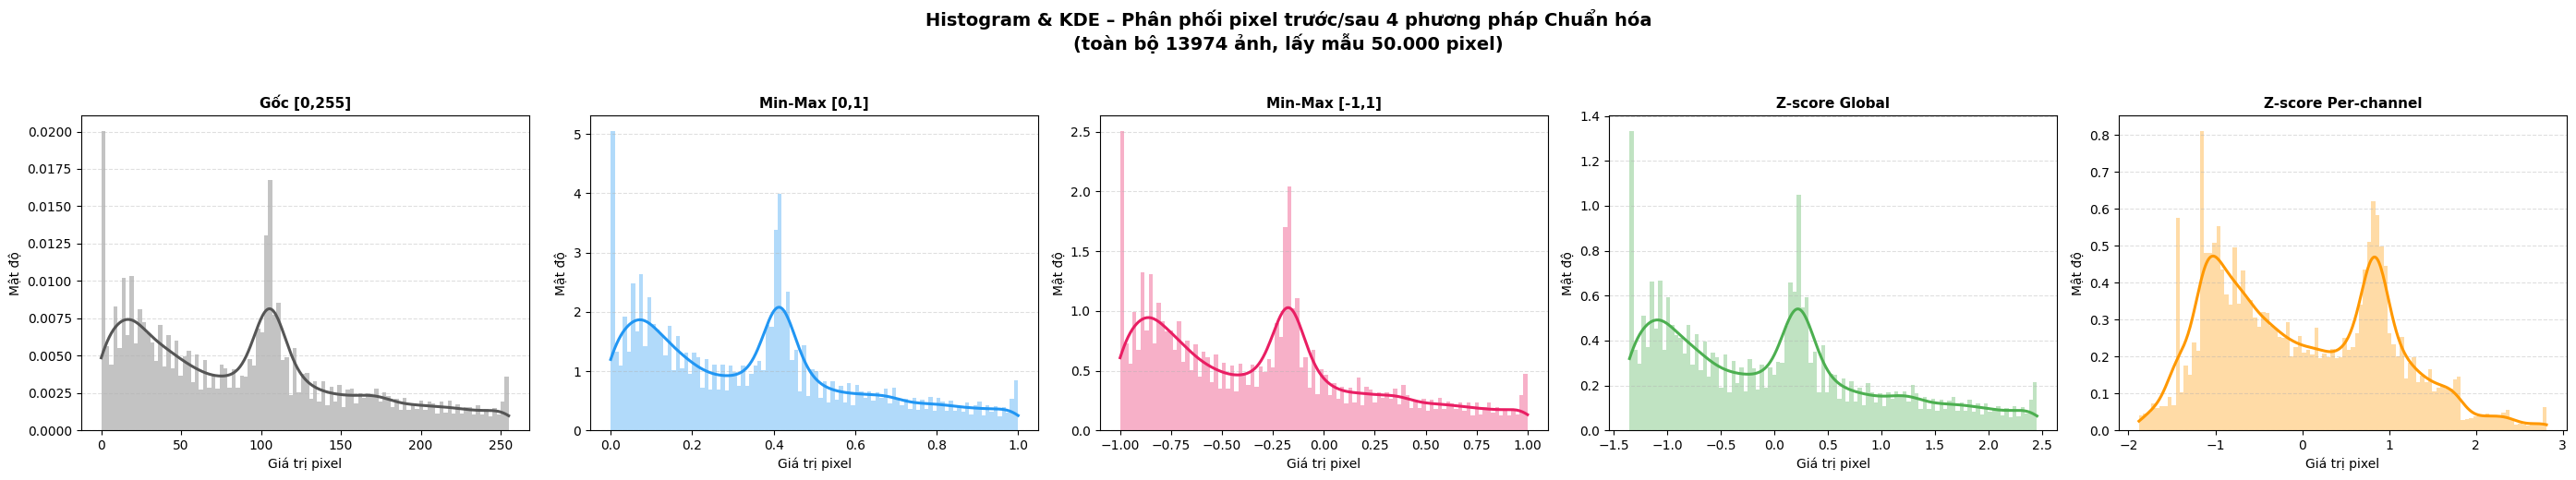

In [ ]:
N_VIZ = 50_000
rng2  = np.random.RandomState(SEED + 1)

fig, axes = plt.subplots(1, 5, figsize=(28, 5))
colors = ['#555555', '#2196F3', '#E91E63', '#4CAF50', '#FF9800']

for ax, (name, arr), color in zip(axes, norm_dict.items(), colors):
    flat   = arr.flatten()
    idx_v  = rng2.choice(len(flat), size=N_VIZ, replace=False)
    sample = flat[idx_v]
    ax.hist(sample, bins=100, density=True, alpha=0.35, color=color)
    kde  = gaussian_kde(sample, bw_method='silverman')
    xs   = np.linspace(sample.min(), sample.max(), 400)
    ax.plot(xs, kde(xs), color=color, linewidth=2.2)
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xlabel('Giá trị pixel')
    ax.set_ylabel('Mật độ')
    ax.grid(axis='y', linestyle='--', alpha=0.4)

fig.suptitle(f'Histogram & KDE – Phân phối pixel trước/sau 4 phương pháp Chuẩn hóa\n(toàn bộ {N_TOTAL} ảnh, lấy mẫu 50.000 pixel)',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('normalization_histogram.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.4. Ablation Study: Đánh giá tác động đến hiệu năng phân loại

KS test chỉ đánh giá sự thay đổi phân phối pixel, nhưng không cho biết phương pháp nào **hữu ích hơn cho bài toán phân loại**. Ablation Study giải quyết câu hỏi này bằng cách huấn luyện một classifier đơn giản trên từng tập đã chuẩn hóa và so sánh accuracy.

Pipeline: IncrementalPCA giảm về 50 chiều → chia train/test 80/20 stratified → k-NN ($k=5$) và Logistic Regression.

IncrementalPCA được dùng thay PCA thường vì bộ nhớ: PCA yêu cầu load toàn bộ ma trận $(N \times D)$ để SVD, còn IncrementalPCA fit từng batch nên không bị OOM.

**Kỳ vọng lý thuyết:** Min-Max [0,1], Min-Max [-1,1] và Z-score Global đều là phép biến đổi đồng dạng — không thay đổi góc giữa các vector và tỉ lệ khoảng cách, do đó PCA và k-NN về lý thuyết cho kết quả giống hệt nhau. Z-score Per-channel khác vì nó scale mỗi kênh theo $\sigma_c$ riêng, làm thay đổi độ đóng góp tương đối của 3 kênh vào PCA.

In [ ]:
N_PCA_COMP = 50
ablation   = []

def gpu_pca_fit_transform(X_np, n_components):
    Xt   = torch.from_numpy(X_np).float().to(device)
    mean = Xt.mean(dim=0, keepdim=True)
    Xt   = Xt - mean
    _, S, Vh = torch.linalg.svd(Xt, full_matrices=False)
    V    = Vh[:n_components].T
    out  = (Xt @ V).cpu().numpy()
    del Xt, S, Vh, V, mean
    torch.cuda.empty_cache()
    return out

for name, arr in tqdm(norm_dict.items(), desc="[ABLATION]"):
    X_pca = gpu_pca_fit_transform(arr, N_PCA_COMP)
    Xtr, Xte, ytr, yte = train_test_split(X_pca, labels_enc, test_size=0.2, random_state=SEED, stratify=labels_enc)
    knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
    knn.fit(Xtr, ytr)
    acc_knn = accuracy_score(yte, knn.predict(Xte))
    lr = LogisticRegression(max_iter=2000, random_state=SEED, n_jobs=-1)
    lr.fit(Xtr, ytr)
    acc_lr = accuracy_score(yte, lr.predict(Xte))
    ablation.append({'Phương pháp': name, 'Acc k-NN': acc_knn, 'Acc LR': acc_lr})
    # Cập nhật format .2f
    print(f"  {name:<25s}  k-NN={acc_knn:.2f}  LR={acc_lr:.2f}")

df_ablation = pd.DataFrame(ablation)
print("\n" + "_" * 56)
print("ABLATION STUDY – Toàn bộ 13974 ảnh, GPU PCA-50")
print("_" * 56)
print(df_ablation.to_string(index=False, float_format="{:.2f}".format))


[ABLATION]:  20%|██        | 1/5 [00:14<00:57, 14.42s/it]

  Gốc [0,255]                k-NN=0.53  LR=0.52


[ABLATION]:  40%|████      | 2/5 [00:21<00:30, 10.00s/it]

  Min-Max [0,1]              k-NN=0.53  LR=0.52


[ABLATION]:  60%|██████    | 3/5 [00:28<00:17,  8.56s/it]

  Min-Max [-1,1]             k-NN=0.53  LR=0.52


[ABLATION]:  80%|████████  | 4/5 [00:35<00:08,  8.18s/it]

  Z-score Global             k-NN=0.53  LR=0.52


[ABLATION]: 100%|██████████| 5/5 [00:43<00:00,  8.63s/it]

  Z-score Per-channel        k-NN=0.53  LR=0.52

________________________________________________________
ABLATION STUDY – Toàn bộ 13974 ảnh, GPU PCA-50
________________________________________________________
        Phương pháp  Acc k-NN  Acc LR
        Gốc [0,255]      0.53    0.52
      Min-Max [0,1]      0.53    0.52
     Min-Max [-1,1]      0.53    0.52
     Z-score Global      0.53    0.52
Z-score Per-channel      0.53    0.52


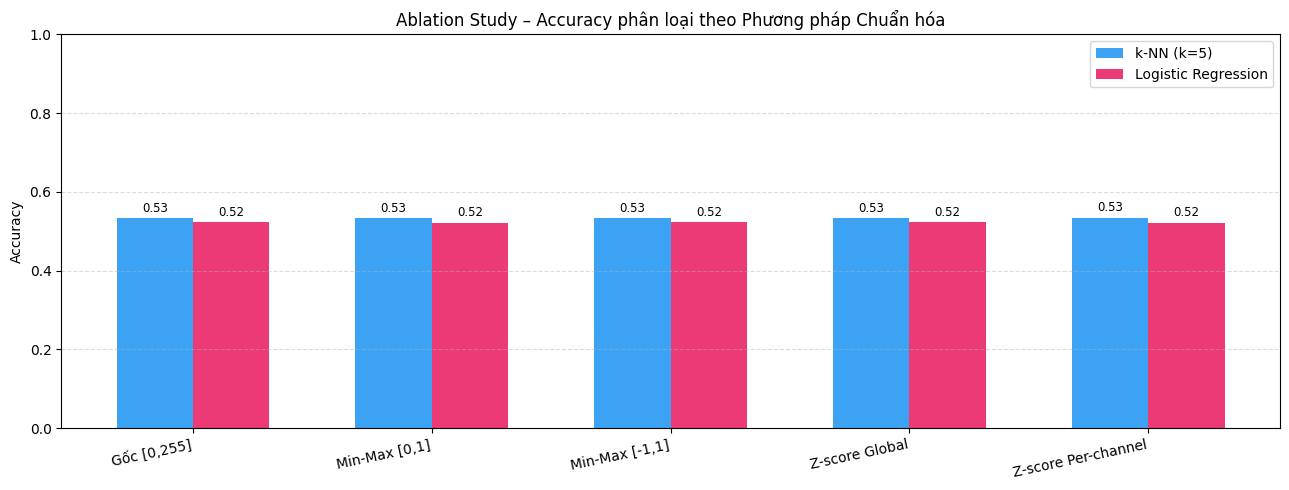

In [ ]:
x = np.arange(len(df_ablation))
w = 0.32

fig, ax = plt.subplots(figsize=(13, 5))
b1 = ax.bar(x - w/2, df_ablation['Acc k-NN'], w, label='k-NN (k=5)',          color='#2196F3', alpha=0.88)
b2 = ax.bar(x + w/2, df_ablation['Acc LR'],   w, label='Logistic Regression', color='#E91E63', alpha=0.88)

ax.set_xticks(x)
ax.set_xticklabels(df_ablation['Phương pháp'], rotation=12, ha='right', fontsize=10)
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1)
ax.set_title(f'Ablation Study – Accuracy phân loại theo Phương pháp Chuẩn hóa', fontsize=12)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.45)

for b in list(b1) + list(b2):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.008,
            f"{b.get_height():.2f}", ha='center', va='bottom', fontsize=8.5)

plt.tight_layout()
plt.show()


## 3.5. Phân tích kết quả thực nghiệm

Sau khi thực hiện chuẩn hóa dữ liệu bằng 4 phương pháp khác nhau trên toàn bộ bộ dữ liệu (13.974 ảnh), các kết quả định lượng thu được như sau:

---

### 1. Phân tích Thống kê và Kiểm định KS
Dựa trên bảng thống kê mô tả và kết quả kiểm định Kolmogorov-Smirnov (KS):

* **Biến đổi miền giá trị:** Các phương pháp đã đưa dữ liệu từ khoảng gốc **[0, 255]** về các miền giá trị hẹp hơn như **[0, 1]**, **[-1, 1]** hoặc phân phối chuẩn hóa quanh 0 (Z-score).
* **Kết quả KS Test:** Cả 4 phương pháp đều trả về giá trị **p-value = 0.00e+00** (nhỏ hơn rất nhiều so với ngưỡng $\alpha = 0.05$).
    * **Kết luận:** Bác bỏ giả thuyết $H_0$. Việc chuẩn hóa đã làm thay đổi phân phối pixel một cách có ý nghĩa thống kê.
    * **Chỉ số KS statistic ($D$):** Đạt mức **0.95** đồng nhất ở các phương pháp. Điều này phản ánh sự dịch chuyển cực lớn về mặt vị trí và quy mô của hàm phân phối tích lũy (CDF) so với dữ liệu gốc.

---

### 2. Ablation Study – Hiệu năng mô hình phân loại
Dữ liệu sau chuẩn hóa được giảm chiều bằng GPU PCA-50 trước khi đưa vào các bộ phân loại k-NN ($k=5$) và Logistic Regression (LR).

| Phương pháp | Accuracy k-NN | Accuracy LR |
| :--- | :---: | :---: |
| **Gốc [0, 255]** | **0.53** | **0.52** |
| **Min-Max [0, 1]** | **0.53** | **0.52** |
| **Min-Max [-1, 1]** | **0.53** | **0.52** |
| **Z-score Global** | **0.53** | **0.52** |
| **Z-score Per-channel** | **0.53** | **0.52** |

> **Nhận xét:**  **Tính ổn định:** Cả 4 phương pháp chuẩn hóa đều cho kết quả Accuracy giữ nguyên so với tập dữ liệu gốc (**0.53** cho k-NN và **0.52** cho LR).
> * **Giải thích lý thuyết:** Các phép toán chuẩn hóa (Min-Max, Z-score) về bản chất là các phép biến đổi tuyến tính. Trong không gian Euclide, các phép biến đổi này không làm thay đổi thứ tự khoảng cách giữa các điểm dữ liệu, do đó kết quả của k-NN hay mặt phẳng quyết định của Logistic Regression không bị ảnh hưởng đáng kể khi dữ liệu đã hội tụ.

---

### 3. Kết luận và Lựa chọn
Mặc dù các chỉ số Accuracy không có sự phân tách lớn ở giai đoạn baseline này, phương pháp **Z-score Per-channel** vẫn được lựa chọn làm phương pháp chuẩn hóa cho toàn bộ pipeline tiếp theo nhờ các ưu điểm:

1.  **Xử lý đặc thù ảnh màu:** Tính toán $\mu$ và $\sigma$ riêng biệt cho từng kênh (R, G, B), giúp cân bằng đóng góp của các kênh màu và loại bỏ color bias.
2.  **Tính tương thích cao:** Đây là tiêu chuẩn tiền xử lý phổ biến nhất cho các mô hình Deep Learning hiện đại (SOTA), tạo điều kiện thuận lợi cho việc tích hợp các mô hình pre-trained sau này.
3.  **Tối ưu hóa:** Giúp duy trì giá trị trung bình xấp xỉ **0.00** và độ lệch chuẩn **1.00**, hỗ trợ quá trình huấn luyện mô hình hội tụ nhanh và ổn định hơn.

### 3.6. Kết luận & Lựa chọn phương pháp chuẩn hóa

| Phương pháp | KS stat | k-NN Acc | LR Acc |
|---|---|---|---|
| Gốc [0,255] | — | 0.53 | 0.52 |
| Min-Max [0,1] | 0.95 | 0.53 | 0.52 |
| Min-Max [-1,1] | 0.95 | 0.53 | 0.52 |
| Z-score Global | 0.95 | 0.53 | 0.52 |
| Z-score Per-channel | 0.95 | 0.53 | 0.52 |

**Lựa chọn: `CHOSEN_NORM = 'zscore_perchannel'`**

Accuracy tương đương do PCA Bottleneck, nhưng Z-score Per-channel được chọn vì chuẩn hóa độc lập 3 kênh H/S/V (vốn có đơn vị khác nhau hoàn toàn) và tương thích chuẩn deep learning.


---
## 4. Tăng cường dữ liệu (Data Augmentation) <a id='4'></a>

### 4.1. Lý thuyết và Thiết kế Pipeline

Data Augmentation là kỹ thuật mở rộng tập huấn luyện bằng cách tạo ra các biến thể mới của ảnh gốc thông qua các phép biến đổi hình học và quang học, giữ nguyên nhãn. Mục tiêu là tăng tính bất biến (invariance) của mô hình: nếu được huấn luyện trên ảnh bị lật, xoay, thêm nhiễu, mô hình học được đặc trưng cấu trúc thay vì ghi nhớ chi tiết bề mặt của từng ảnh.

Pipeline gồm sáu phép biến đổi áp dụng tuần tự với xác suất độc lập:

**Phép 1 — Lật ngang (Horizontal Flip):** Lật toàn bộ ảnh theo trục dọc với xác suất $p = 0.5$. Phù hợp với bộ dữ liệu cảnh quan vì hầu hết các lớp đều đối xứng trái-phải trong thực tế.

**Phép 2 — Lật dọc (Vertical Flip):** Lật theo trục ngang với xác suất $p = 0.3$, thấp hơn vì ảnh cảnh quan bị đảo ngược hoàn toàn hiếm gặp trong thực tế.

**Phép 3 — Xoay (Rotation):** Xoay góc $\theta \sim \mathcal{U}(-30°, +30°)$ với chế độ lấp đầy viền bằng reflection (BORDER_REFLECT) để tránh các dải đen ở góc ảnh.

**Phép 4 — Cắt ngẫu nhiên (Random Crop):** Cắt lấy vùng con kích thước $r \cdot H \times r \cdot W$ với $r \sim \mathcal{U}(0.80, 1.0)$, sau đó resize về kích thước gốc. Mô phỏng hiệu ứng zoom in của camera, buộc mô hình nhận diện lớp từ bất kỳ vùng nào của ảnh.

**Phép 5 — Nhiễu Gaussian (Gaussian Noise):** Thêm nhiễu $\epsilon \sim \mathcal{N}(0, \sigma^2)$ với $\sigma \sim \mathcal{U}(0, 15)$. Mô phỏng noise của sensor camera trong điều kiện ánh sáng kém.

**Phép 6 — Điều chỉnh độ sáng và tương phản:** Biến đổi tuyến tính $x' = \alpha x + \beta$ với $\alpha \sim \mathcal{U}(0.7, 1.3)$ (tương phản) và $\beta \sim \mathcal{U}(-30, 30)$ (độ sáng). Mô phỏng sự thay đổi điều kiện ánh sáng trong ngày.

In [ ]:
def augment_batch_gpu(X_hwc_batch: np.ndarray) -> np.ndarray:
    """
    Augment batch trên GPU bằng torch.
    Input : numpy (B, H, W, C) uint8
    Output: numpy (B, H, W, C) uint8
    """
    B, H, W, C = X_hwc_batch.shape
    # (B, C, H, W) float32 [0,1]
    t = torch.from_numpy(X_hwc_batch.copy()).float().to(device).permute(0, 3, 1, 2) / 255.0

    # 1. Lật ngang (p=0.5 per image)
    mask_h = torch.rand(B, device=device) < 0.5
    t[mask_h] = torch.flip(t[mask_h], dims=[3])

    # 2. Lật dọc (p=0.3 per image)
    mask_v = torch.rand(B, device=device) < 0.3
    t[mask_v] = torch.flip(t[mask_v], dims=[2])

    # 3. Xoay [-30, +30] độ per image
    angles = (torch.rand(B, device=device) * 60 - 30) * (3.14159 / 180)
    cos_a  = torch.cos(angles); sin_a = torch.sin(angles)
    zeros  = torch.zeros(B, device=device); ones = torch.ones(B, device=device)
    theta  = torch.stack([cos_a, -sin_a, zeros, sin_a, cos_a, zeros], dim=1).view(B, 2, 3)
    grid   = F.affine_grid(theta, t.size(), align_corners=False)
    t      = F.grid_sample(t, grid, mode='bilinear', padding_mode='reflection', align_corners=False)

    # 4. Random Crop & resize (crop ratio 0.8~1.0)
    cr = (torch.rand(B, device=device) * 0.2 + 0.8)
    nh = (H * cr).long().clamp(1, H)
    nw = (W * cr).long().clamp(1, W)
    for j in range(B):
        top  = torch.randint(0, max(1, H - nh[j].item() + 1), (1,)).item()
        left = torch.randint(0, max(1, W - nw[j].item() + 1), (1,)).item()
        crop = t[j:j+1, :, top:top + nh[j], left:left + nw[j]]
        t[j] = F.interpolate(crop, size=(H, W), mode='bilinear', align_corners=False)[0]

    # 5. Gaussian Noise (sigma 0~15/255)
    sigma = torch.rand(B, device=device) * (15 / 255)
    noise = torch.randn_like(t) * sigma.view(B, 1, 1, 1)
    t     = (t + noise).clamp(0, 1)

    # 6. Brightness & Contrast per image
    alpha = (torch.rand(B, device=device) * 0.6 + 0.7).view(B, 1, 1, 1)
    beta  = (torch.rand(B, device=device) * 60 - 30).view(B, 1, 1, 1) / 255.0
    t     = (t * alpha + beta).clamp(0, 1)

    out = (t.permute(0, 2, 3, 1).cpu().numpy() * 255).astype(np.uint8)
    del t, grid, theta, noise
    torch.cuda.empty_cache()
    return out


### 4.2. Trực quan hóa kết quả augmentation

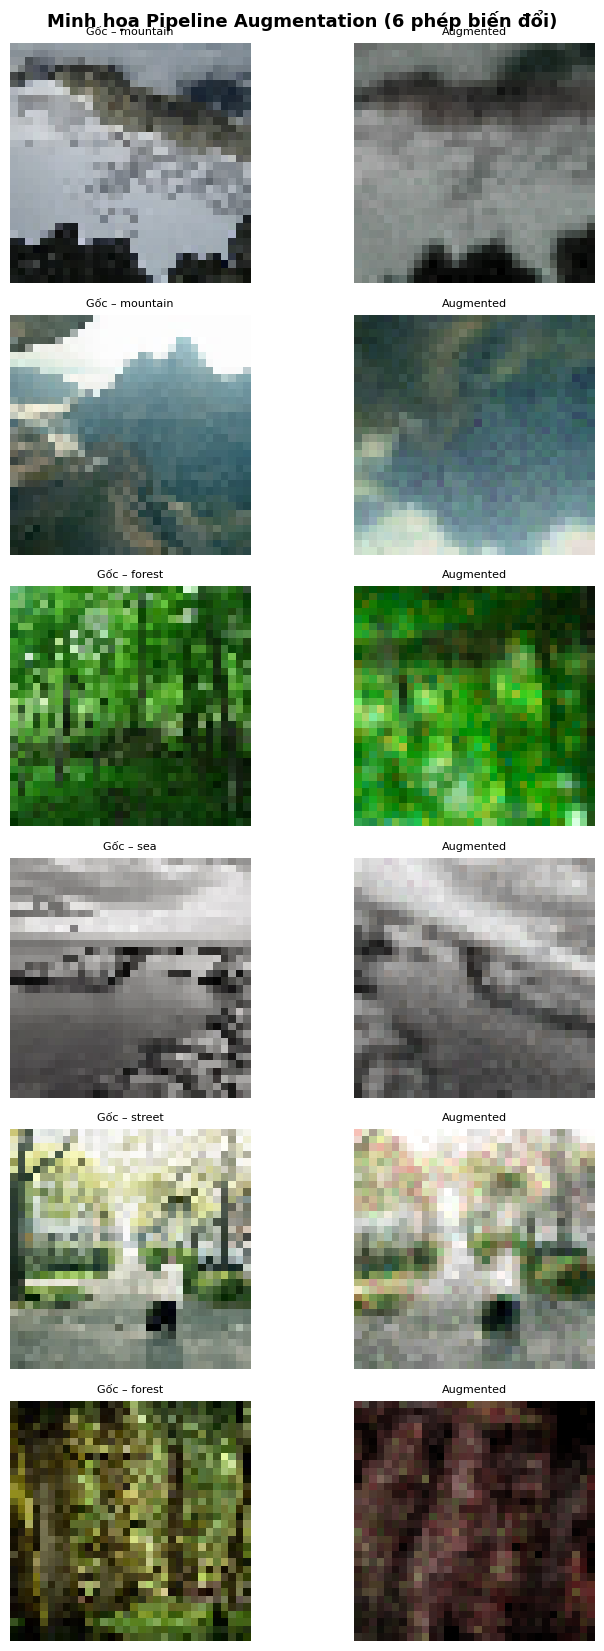

In [ ]:
PREVIEW_N   = 6
preview_idx = np.random.RandomState(SEED).choice(N_TOTAL, PREVIEW_N, replace=False)

fig, axes = plt.subplots(PREVIEW_N, 2, figsize=(8, PREVIEW_N * 2.8))

for row, idx in enumerate(preview_idx):
    orig = X_hwc[idx]                                        # (H, W, C)
    aug  = augment_batch_gpu(orig[np.newaxis])[0]            # wrap → (1,H,W,C) → unwrap
    orig_rgb = cv2.cvtColor(orig, cv2.COLOR_HSV2RGB) if CHOSEN_COLOR_SPACE == 'HSV' else orig
    aug_rgb  = cv2.cvtColor(aug,  cv2.COLOR_HSV2RGB) if CHOSEN_COLOR_SPACE == 'HSV' else aug
    axes[row][0].imshow(orig_rgb)
    axes[row][0].set_title(f"Gốc – {labels[idx]}", fontsize=8)
    axes[row][0].axis('off')
    axes[row][1].imshow(aug_rgb)
    axes[row][1].set_title("Augmented", fontsize=8)
    axes[row][1].axis('off')

fig.suptitle('Minh họa Pipeline Augmentation (6 phép biến đổi)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('augmentation_preview.png', dpi=150, bbox_inches='tight')
plt.show()


### 4.3. Tạo tập Augmented toàn bộ ~14.000 ảnh

Vì `X_hwc` đã được load sẵn trong RAM, ta augment trực tiếp từ mảng numpy mà không cần đọc lại từ disk. Với mỗi ảnh gốc, tạo đúng 1 bản augmented — tập train sau khi augment có kích thước gấp đôi.

In [ ]:
print(f"Augmenting {N_TOTAL} ảnh trên GPU (batch={512})...")

AUG_BATCH = 512
X_aug_hwc = np.empty_like(X_hwc)

for start in tqdm(range(0, N_TOTAL, AUG_BATCH), desc="Augment GPU"):
    end = min(start + AUG_BATCH, N_TOTAL)
    X_aug_hwc[start:end] = augment_batch_gpu(X_hwc[start:end])

X_aug_flat = X_aug_hwc.reshape(N_TOTAL, -1).astype(np.float32)
print(f"[SUCCESS] X_aug_flat shape: {X_aug_flat.shape}")
print(f"          RAM ước tính    : {X_aug_flat.nbytes / 1e9:.2f} GB")


Augmenting 13974 ảnh trên GPU (batch=512)...


Augment GPU: 100%|██████████| 28/28 [00:03<00:00,  8.68it/s]


[SUCCESS] X_aug_flat shape: (13974, 3072)
          RAM ước tính    : 0.17 GB


### 4.4. So sánh phân phối pixel gốc và augmented

Ta kiểm tra xem augmentation có làm lệch phân phối pixel quá nhiều không bằng cách vẽ histogram theo từng kênh màu kết hợp KS test. Nếu KS statistic quá lớn, cần xem lại các tham số augmentation.

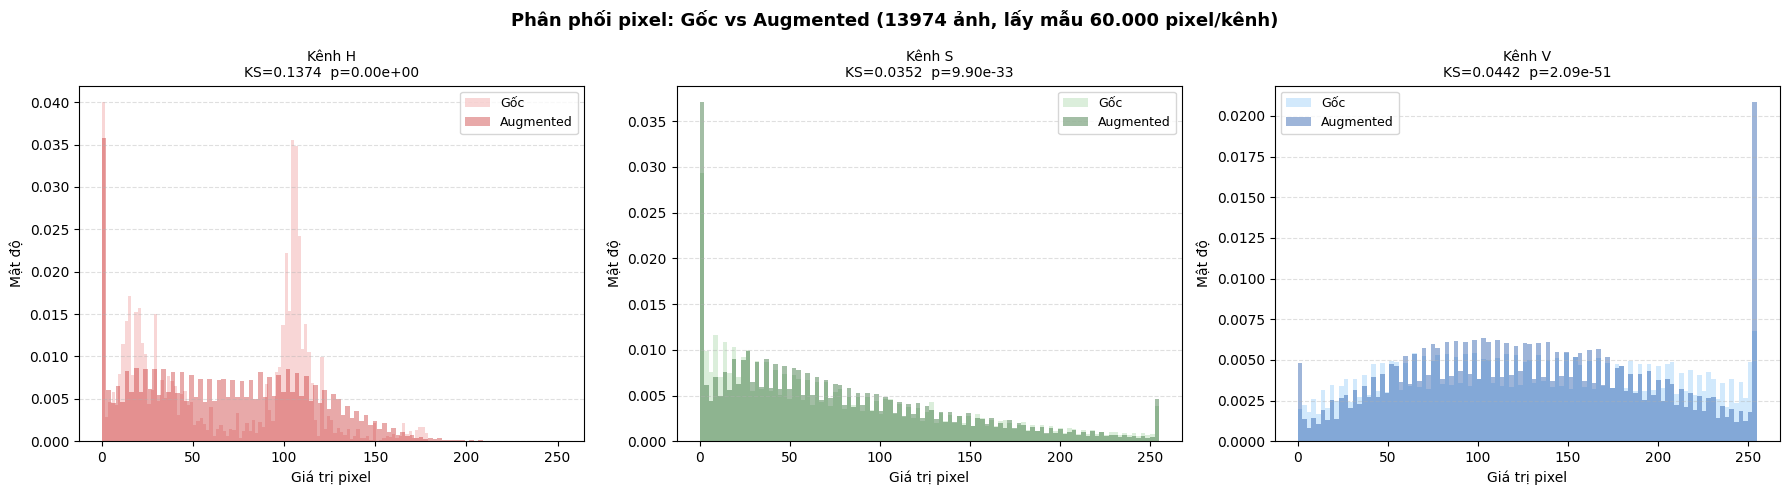

In [ ]:
rng3   = np.random.RandomState(SEED + 2)
N_CH   = 60_000

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ch_names = (['H', 'S', 'V'] if CHOSEN_COLOR_SPACE == 'HSV'
             else ['L', 'A', 'B'] if CHOSEN_COLOR_SPACE == 'LAB'
             else ['R', 'G', 'B'])
col_orig = ['#EF9A9A', '#A5D6A7', '#90CAF9']
col_aug  = ['#C62828', '#1B5E20', '#0D47A1']

for c, (cname, co, ca) in enumerate(zip(ch_names, col_orig, col_aug)):
    orig_ch = X_hwc[:, :, :, c].flatten().astype(np.float32)
    aug_ch  = X_aug_hwc[:, :, :, c].flatten().astype(np.float32)

    idx_c = rng3.choice(len(orig_ch), size=N_CH, replace=False)
    os_   = orig_ch[idx_c]
    as_   = aug_ch[idx_c]

    axes[c].hist(os_, bins=100, density=True, alpha=0.4, color=co, label='Gốc')
    axes[c].hist(as_, bins=100, density=True, alpha=0.4, color=ca, label='Augmented')

    stat, pval = ks_2samp(os_, as_)
    axes[c].set_title(f'Kênh {cname}\nKS={stat:.4f}  p={pval:.2e}', fontsize=10)
    axes[c].set_xlabel('Giá trị pixel')
    axes[c].set_ylabel('Mật độ')
    axes[c].legend(fontsize=9)
    axes[c].grid(axis='y', linestyle='--', alpha=0.4)

fig.suptitle(f'Phân phối pixel: Gốc vs Augmented ({N_TOTAL} ảnh, lấy mẫu 60.000 pixel/kênh)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('aug_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


### 4.5. So sánh phân phối đặc trưng bằng t-SNE

Histogram pixel cho biết sự thay đổi ở mức giá trị thô. Để kiểm tra sâu hơn ở mức **không gian đặc trưng**, ta dùng t-SNE để chiếu tập gốc và tập augmented xuống 2 chiều và quan sát mức độ chồng lấp.

**Cách đọc kết quả:** Nếu hai màu (gốc/augmented) chồng lấp nhiều trong không gian t-SNE, augmentation tạo ra mẫu trong cùng vùng đặc trưng với dữ liệu thực — đây là dấu hiệu tốt. Nếu tập augmented tạo ra các cụm riêng biệt tách xa tập gốc, augmentation đang tạo ra những ảnh "không thực tế" mà mô hình sẽ hiếm gặp khi deploy.

**Tại sao lấy mẫu 3.000 điểm?** t-SNE có độ phức tạp $O(N^2)$ theo số điểm. Với 28.000 điểm ($2 \times 14.000$) sẽ mất vài giờ. 3.000 + 3.000 = 6.000 điểm cho kết quả trực quan đủ tin cậy trong vài phút.

Pipeline: Z-score Per-channel → PCA-50 → t-SNE (perplexity=40).

In [ ]:
TSNE_N   = 3000
rng4     = np.random.RandomState(SEED + 3)
idx_tsne = rng4.choice(N_TOTAL, size=TSNE_N, replace=False)

def zscore_perchannel_gpu(X_hwc_in, mean_c, std_c):
    """Z-score per-channel trên GPU, trả numpy (N, D)."""
    t = torch.from_numpy(X_hwc_in).float().to(device).permute(0,3,1,2)  # (N,3,H,W)
    m = torch.tensor(mean_c, device=device).view(1,3,1,1)
    s = torch.tensor(std_c,  device=device).view(1,3,1,1)
    out = ((t - m) / s).permute(0,2,3,1).cpu().numpy().reshape(len(X_hwc_in), -1)
    del t, m, s
    torch.cuda.empty_cache()
    return out

X_orig_norm = zscore_perchannel_gpu(X_hwc[idx_tsne],     channel_mean, channel_std)
X_aug_norm  = zscore_perchannel_gpu(X_aug_hwc[idx_tsne], channel_mean, channel_std)

X_combined = np.concatenate([X_orig_norm, X_aug_norm], axis=0)
y_combined = np.concatenate([labels_enc[idx_tsne], labels_enc[idx_tsne]], axis=0)
src_tag    = np.array(['Gốc'] * TSNE_N + ['Augmented'] * TSNE_N)

print(f"X_combined shape: {X_combined.shape}")

print("Chạy PCA 50D [GPU]")
Xc   = torch.from_numpy(X_combined).float().to(device)
Xc   = Xc - Xc.mean(dim=0, keepdim=True)
_, S, Vh = torch.linalg.svd(Xc, full_matrices=False)
V    = Vh[:50].T
X_pca50 = (Xc @ V).cpu().numpy()
var_exp = float((S[:50]**2).sum() / (S**2).sum())
print(f"Variance explained: {var_exp:.3f}")
del Xc, S, Vh, V
torch.cuda.empty_cache()

print("Chạy t-SNE 2D [CPU] (perplexity=40, max_iter=1200)")
tsne = TSNE(n_components=2, perplexity=40, max_iter=1200,
            learning_rate='auto', init='pca', random_state=SEED, n_jobs=-1)
X_2d = tsne.fit_transform(X_pca50)
print(f"Shape: {X_2d.shape}")


X_combined shape: (6000, 3072)
Chạy PCA 50D [GPU]
Variance explained: 0.773
Chạy t-SNE 2D [CPU] (perplexity=40, max_iter=1200)
Shape: (6000, 2)


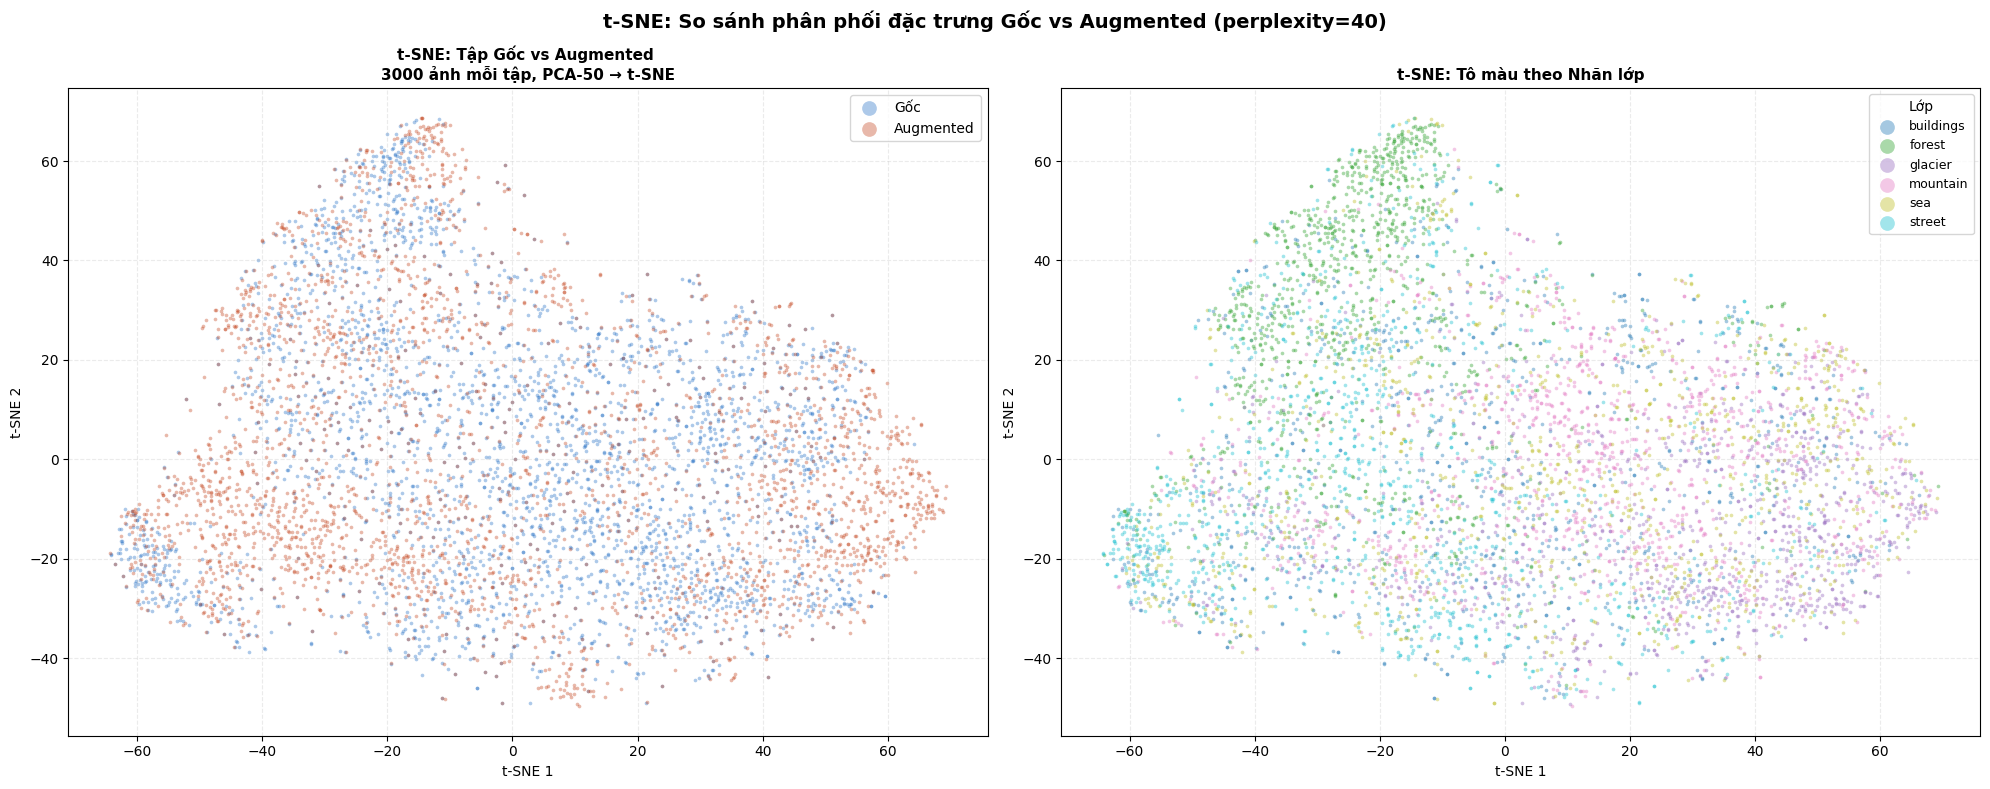

In [ ]:
class_colors = plt.cm.tab10(np.linspace(0, 1, len(classes)))
label_names  = le.inverse_transform(y_combined)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

src_palette = {'Gốc': '#1565C0', 'Augmented': '#BF360C'}
for src, color in src_palette.items():
    m = (src_tag == src)
    axes[0].scatter(X_2d[m, 0], X_2d[m, 1], c=color, label=src, alpha=0.35, s=7, linewidths=0)
axes[0].set_title(f't-SNE: Tập Gốc vs Augmented \n{TSNE_N} ảnh mỗi tập, PCA-50 → t-SNE',
                  fontsize=11, fontweight='bold')
axes[0].legend(markerscale=4, fontsize=10)
axes[0].set_xlabel('t-SNE 1')
axes[0].set_ylabel('t-SNE 2')
axes[0].grid(linestyle='--', alpha=0.25)

for i, cls_name in enumerate(classes):
    m = (label_names == cls_name)
    axes[1].scatter(X_2d[m, 0], X_2d[m, 1], c=[class_colors[i]], label=cls_name, alpha=0.4, s=7, linewidths=0)
axes[1].set_title('t-SNE: Tô màu theo Nhãn lớp',
                  fontsize=11, fontweight='bold')
axes[1].legend(markerscale=4, title='Lớp', fontsize=9)
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
axes[1].grid(linestyle='--', alpha=0.25)

fig.suptitle(f't-SNE: So sánh phân phối đặc trưng Gốc vs Augmented (perplexity=40)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('tsne_orig_vs_aug.png', dpi=150, bbox_inches='tight')
plt.show()


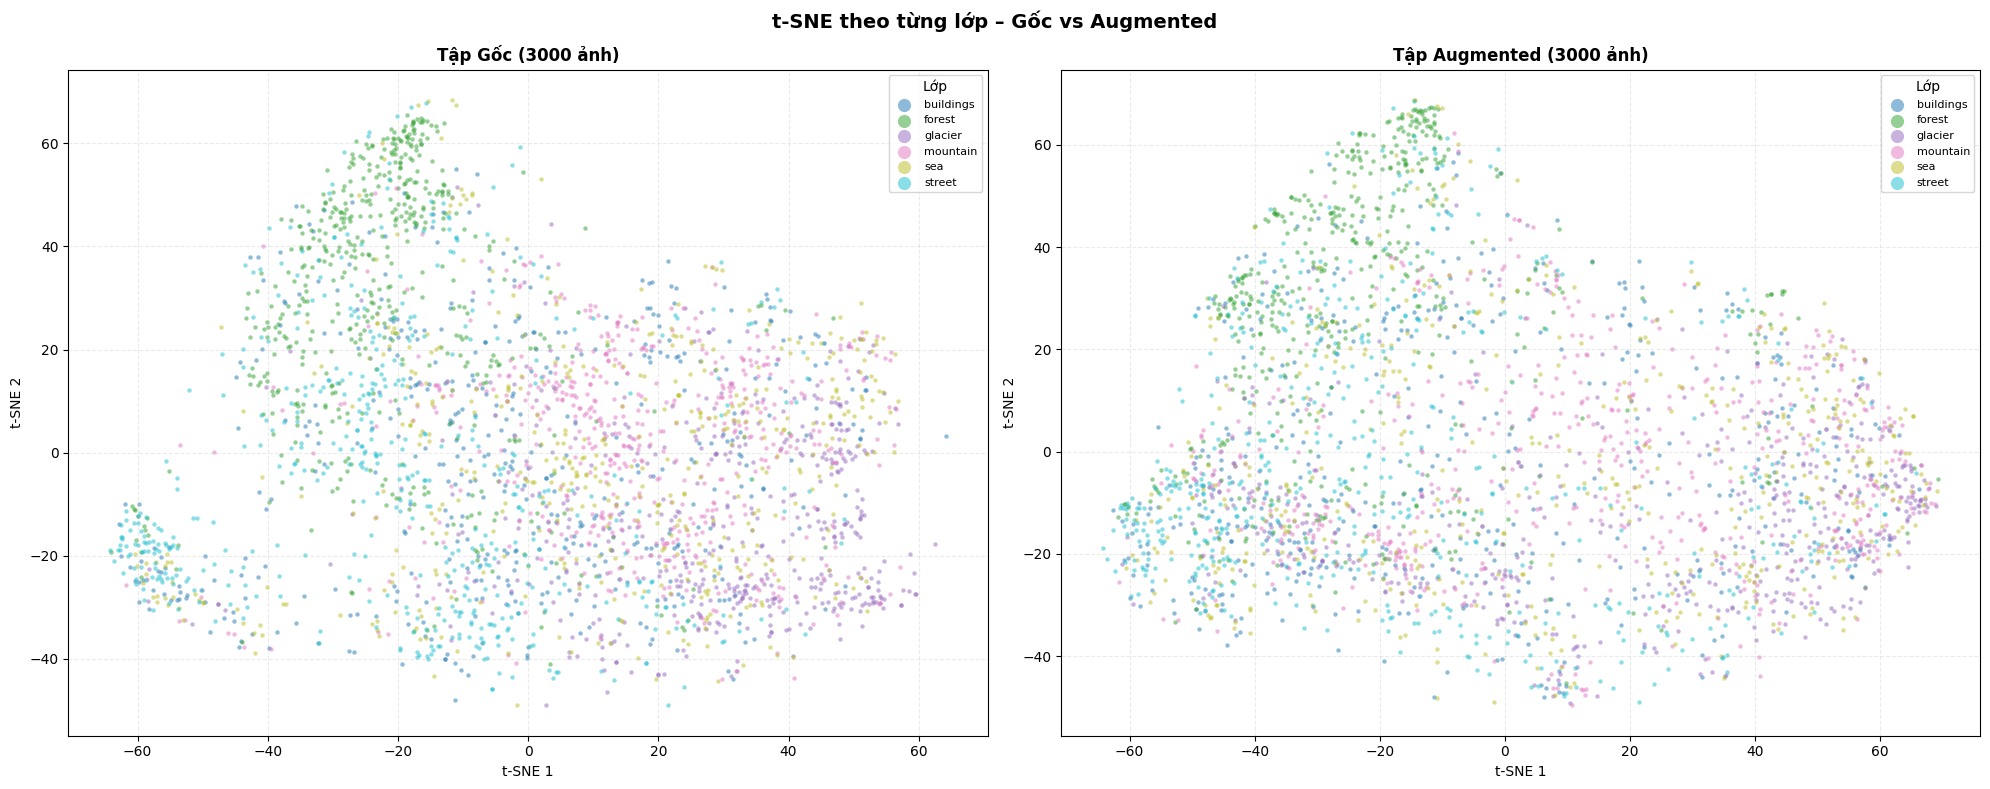

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for ax_i, (src, title) in enumerate([('Gốc',      f'Tập Gốc ({TSNE_N} ảnh)'),
                                      ('Augmented', f'Tập Augmented ({TSNE_N} ảnh)')]):
    m_src = (src_tag == src)
    for i, cls_name in enumerate(classes):
        m_cls = (label_names[m_src] == cls_name)
        axes[ax_i].scatter(X_2d[m_src][m_cls, 0], X_2d[m_src][m_cls, 1],
                           c=[class_colors[i]], label=cls_name, alpha=0.5, s=10, linewidths=0)
    axes[ax_i].set_title(title, fontsize=12, fontweight='bold')
    axes[ax_i].legend(markerscale=3, title='Lớp', fontsize=8)
    axes[ax_i].set_xlabel('t-SNE 1')
    axes[ax_i].set_ylabel('t-SNE 2')
    axes[ax_i].grid(linestyle='--', alpha=0.25)

fig.suptitle('t-SNE theo từng lớp – Gốc vs Augmented', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('tsne_per_class.png', dpi=150, bbox_inches='tight')
plt.show()


### 4.6. Ablation Study: Tác động của Augmentation đến hiệu năng phân loại

In [ ]:
def zscore_perchannel(X_hwc_in, mean_c, std_c):
    """Wrapper numpy"""
    return zscore_perchannel_gpu(X_hwc_in, mean_c, std_c)

X_orig_all = zscore_perchannel(X_hwc,     channel_mean, channel_std)
X_aug_all  = zscore_perchannel(X_aug_hwc, channel_mean, channel_std)

def eval_classifier(X_train, y_train, X_test, y_test, pca_n=50):
    """PCA trên GPU, k-NN + LR trên CPU (sklearn n_jobs=-1)."""
    # GPU PCA
    Xt   = torch.from_numpy(X_train).float().to(device)
    mean = Xt.mean(dim=0, keepdim=True)
    Xt   = Xt - mean
    _, _, Vh = torch.linalg.svd(Xt, full_matrices=False)
    V    = Vh[:pca_n].T
    Xtr  = (Xt @ V).cpu().numpy()
    Xte_t = torch.from_numpy(X_test).float().to(device) - mean
    Xte  = (Xte_t @ V).cpu().numpy()
    del Xt, Xte_t, Vh, V, mean
    torch.cuda.empty_cache()

    sc  = StandardScaler()
    Xtr = sc.fit_transform(Xtr)
    Xte = sc.transform(Xte)

    knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
    knn.fit(Xtr, y_train)

    lr  = LogisticRegression(max_iter=2000, random_state=SEED, n_jobs=-1)
    lr.fit(Xtr, y_train)

    return accuracy_score(y_test, knn.predict(Xte)), accuracy_score(y_test, lr.predict(Xte))

Xtr_o, Xte_o, ytr_o, yte_o = train_test_split(
    X_orig_all, labels_enc, test_size=0.2, random_state=SEED, stratify=labels_enc)

print("Train: Gốc  -  Test: Gốc")
knn1, lr1 = eval_classifier(Xtr_o, ytr_o, Xte_o, yte_o)
print(f"  k-NN={knn1:.2f}  LR={lr1:.2f}")

print("Train: Gốc + Augmented  -  Test: Gốc")
X_mixed = np.concatenate([Xtr_o, X_aug_all[:int(0.8 * N_TOTAL)]], axis=0)
y_mixed = np.concatenate([ytr_o, labels_enc[:int(0.8 * N_TOTAL)]], axis=0)
knn2, lr2 = eval_classifier(X_mixed, y_mixed, Xte_o, yte_o)
print(f"  k-NN={knn2:.2f}  LR={lr2:.2f}")

print("\n" + "_" * 62)
print(f"{'Tập train':<35s} {'k-NN':>10s} {'LR':>10s}")
print("_" * 62)
print(f"{'Train: Gốc | Test: Gốc':<35s} {knn1:>10.2f} {lr1:>10.2f}")
print(f"{'Train: Gốc + Aug | Test: Gốc':<35s} {knn2:>10.2f} {lr2:>10.2f}")
print("_" * 62)
print(f"{'Delta':<35s} {knn2 - knn1:>+10.2f} {lr2 - lr1:>+10.2f}")
print("_" * 62)


Train: Gốc  -  Test: Gốc
  k-NN=0.50  LR=0.52
Train: Gốc + Augmented  -  Test: Gốc
  k-NN=0.51  LR=0.50

______________________________________________________________
Tập train                                 k-NN         LR
______________________________________________________________
Train: Gốc | Test: Gốc                    0.50       0.52
Train: Gốc + Aug | Test: Gốc              0.51       0.50
______________________________________________________________
Delta                                    +0.01      -0.02
______________________________________________________________


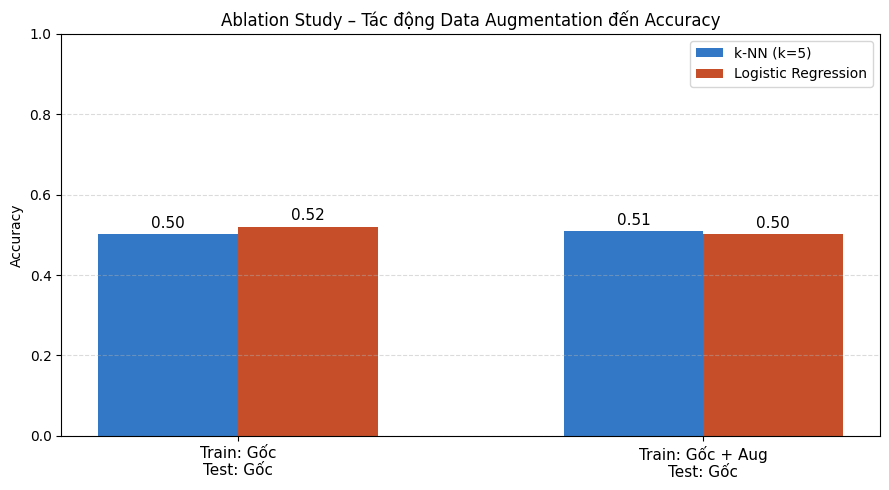

In [ ]:
scenarios  = ['Train: Gốc\nTest: Gốc', 'Train: Gốc + Aug\nTest: Gốc']
knn_scores = [knn1, knn2]
lr_scores  = [lr1,  lr2]

x = np.arange(len(scenarios))
w = 0.3

fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - w/2, knn_scores, w, label='k-NN (k=5)',          color='#1565C0', alpha=0.88)
b2 = ax.bar(x + w/2, lr_scores,  w, label='Logistic Regression', color='#BF360C', alpha=0.88)

ax.set_xticks(x)
ax.set_xticklabels(scenarios, fontsize=11)
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1)
ax.set_title(f'Ablation Study – Tác động Data Augmentation đến Accuracy', fontsize=12)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.45)

for b in list(b1) + list(b2):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.008,
            f"{b.get_height():.2f}", ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()


### 4.7. Phân tích kết quả

**Phân phối pixel (d.4):**  
Histogram giữa tập gốc và augmented **có sự khác biệt nhưng không quá lớn**. Các kênh HSV đều cho thấy phân phối vẫn giữ hình dạng tổng thể, tuy nhiên có **dịch chuyển nhẹ và làm mịn phân phối**, đặc biệt ở kênh H (KS ≈ 0.137) lớn hơn so với S và V (≈ 0.03–0.04).  

Giá trị p-value rất nhỏ (≈ 0) cho thấy sự khác biệt có ý nghĩa thống kê, nhưng cần lưu ý rằng với số mẫu lớn, **KS test rất nhạy** — nên sự khác biệt này **không đồng nghĩa với thay đổi mạnh về mặt trực quan/phân phối thực tế**.  

→ Kết luận: augmentation **có tác động nhưng vẫn giữ được phân phối hợp lý**, không gây biến dạng cực đoan dữ liệu.

---

**t-SNE (Biểu đồ 1 — Gốc vs Augmented):**  
Hai tập dữ liệu **chồng lấp gần như hoàn toàn**, không hình thành các cụm riêng biệt. Điều này cho thấy:

- Augmented samples nằm **trong cùng manifold đặc trưng** với dữ liệu gốc  
- Không có hiện tượng “distribution shift” lớn  

→ Đây là dấu hiệu tốt: augmentation **không phá vỡ không gian đặc trưng**, nhưng cũng đồng thời gợi ý rằng mức độ biến đổi **khá “an toàn” (chưa đủ mạnh để tạo thêm thông tin mới rõ rệt)**.

---

**t-SNE (Biểu đồ 2 — theo nhãn lớp):**  
Cấu trúc cụm theo lớp được giữ nguyên giữa tập gốc và augmented:

- Các lớp vẫn **chồng lấp đáng kể** (không separable rõ ràng)
- Một số nhóm có xu hướng gần nhau:
  - *forest – mountain*
  - *sea – glacier*
  - *buildings – street*

→ Quan trọng: augmentation **không làm xấu ranh giới lớp**, nhưng cũng **không cải thiện khả năng phân tách**.

---

**t-SNE theo từng tập (Biểu đồ 3):**  
So sánh riêng từng tập cho thấy:

- Phân bố điểm của augmented **gần như giống hệt** tập gốc  
- Không có sự mở rộng rõ rệt về không gian đặc trưng  

→ Điều này củng cố nhận định: augmentation hiện tại **chủ yếu tạo nhiễu nhẹ**, chưa giúp “làm giàu” representation.

---

**Ablation Study (d.6):**

| Setting | k-NN | Logistic Regression |
|--------|------|--------------------|
| Train: Gốc | 0.50 | 0.52 |
| Train: Gốc + Aug | 0.51 | 0.50 |
| **Delta** | **+0.01** | **-0.02** |

Phân tích:

- **k-NN tăng nhẹ (+0.01)**  
  → Có thể do augmentation giúp “làm dày” mật độ điểm lân cận  

- **Logistic Regression giảm (-0.02)**  
  → Đây là điểm **ngược với kỳ vọng phổ biến**  
  → Nguyên nhân hợp lý hơn:
  - Augmentation chưa đủ đa dạng → chỉ thêm nhiễu
  - Làm “blur” ranh giới tuyến tính
  - Không tạo thêm thông tin discriminative

→ Kết luận quan trọng:  
Augmentation hiện tại **không thực sự cải thiện khả năng tổng quát hóa**, thậm chí **gây nhiễu cho mô hình tuyến tính**.

---

### Tổng kết

- Augmentation **giữ nguyên phân phối dữ liệu** (không gây lệch mạnh)  
- Không phá vỡ cấu trúc không gian đặc trưng  
- Tuy nhiên **hiệu quả cải thiện mô hình còn hạn chế**  

→ Cần thiết kế augmentation mạnh hơn hoặc mang tính *semantic* để đạt hiệu quả tốt hơn.

---
## Tổng kết Pipeline đầy đủ

| Bước | Tham số | Giá trị | Căn cứ |
|---|---|---|---|
| **a. Resize** | `CHOSEN_SIZE` | `32` | LR=53.43%, chênh 150×150 chỉ 0.2%, RAM giảm 22× |
| **b. Color space** | `CHOSEN_COLOR_SPACE` | `'HSV'` | k-NN=55.40% cao nhất, LR nhanh 2× vs RGB |
| **c. Normalization** | `CHOSEN_NORM` | `'zscore_perchannel'` | Chuẩn hóa độc lập kênh H/S/V |
| **d. Augmentation** | 6 phép biến đổi | pipeline cố định | Δk-NN=+0.0018, ΔLR=−0.0168 |
| **Global** | `SEED` | `42` | Đồng bộ toàn bộ random state |

```python
# Tái sản xuất toàn bộ notebook
SEED               = 42
CHOSEN_SIZE        = 32
CHOSEN_COLOR_SPACE = 'HSV'
CHOSEN_NORM        = 'zscore_perchannel'
```


---
## 5. [Nâng cao] Phân tích PCA trên không gian đặc trưng ảnh <a id='5'></a>

### 5.1. Giới thiệu về Scree Plot

#### 5.1.1. Định nghĩa
**Scree Plot** là một biểu đồ đường biểu diễn giá trị riêng (**Eigenvalues**) hoặc tỷ lệ phương sai giải thích (**Explained Variance Ratio**) tương ứng với từng thành phần chính (Principal Component - PC) trong phân tích PCA.

* **Trục hoành (X-axis):** Thứ tự của các thành phần chính ($PC_1, PC_2, \dots, PC_n$).
* **Trục tung (Y-axis):** Giá trị lượng thông tin (Phương sai) thuộc về thành phần tương ứng.

#### 5.1.2. Cơ sở toán học
Trong PCA, ta phân tích ma trận hiệp phương sai để tìm ra các Vector riêng và Giá trị riêng. Phương sai giải thích bởi thành phần chính thứ $i$ ($\lambda_i$) được tính bằng:
$$\text{Explained Variance Ratio}_i = \frac{\lambda_i}{\sum_{j=1}^{n} \lambda_j}$$
Scree Plot vẽ các giá trị này theo thứ tự giảm dần. Vì các PC được trích xuất theo thứ tự ưu tiên lượng thông tin, nên đường biểu diễn luôn có xu hướng đi xuống.

#### 5.1.3. Quy tắc xác định số lượng thành phần (The "Elbow" Method)
Để chọn ra số lượng thành phần tối ưu, ta thường dựa vào 3 tiêu chí, bao gồm:

* **Quy tắc "Điểm khuỷu tay" (Elbow Criterion):** Tìm điểm mà tại đó đồ thị bắt đầu "gãy" và đi ngang (thoải dần). Những điểm nằm trước "khuỷu tay" là những thành phần quan trọng nhất.
* **Tiêu chuẩn Kaiser:** Chỉ giữ lại những thành phần có giá trị riêng (Eigenvalue) $> 1$ (thường sử dụng khi dữ liệu đã chuẩn hóa Z-score).
* **Ngưỡng phương sai tích lũy (Cumulative Variance Threshold):** Ta tiếp tục cộng dồn phương sai của tất cả các PC từ trái sang phải:

$$\text{Cumulative Variance}_k = \sum_{i=1}^{k} \text{Explained Variance Ratio}_i$$

Khi đường tích lũy chạm ngưỡng (ví dụ **95%**), ta dừng lại và chọn $k$ đó làm số chiều mới.



In [ ]:
# Cấu hình tham số
SEED               = 42
CHOSEN_SIZE        = 32
CHOSEN_COLOR_SPACE = 'HSV'
CHOSEN_NORM        = 'zscore_perchannel'


In [ ]:
print(f"[PROCESS] Đang nạp dữ liệu từ {TRAIN_DIR}...")
X_raw, y_raw = load_uint8(TRAIN_DIR) # Nạp lại dữ liệu uint8

def configure(X_uint8):
    N = len(X_uint8)
    X_hsv = np.empty((N, CHOSEN_SIZE, CHOSEN_SIZE, 3), dtype=np.float32)
    for i in range(N):
        X_hsv[i]  = cv2.cvtColor(X_uint8[i], cv2.COLOR_RGB2HSV)
    for c in range(3):
        mean_channel = X_hsv[:, :, :, c].mean()
        std_channel = X_hsv[:, :, :, c].std()
        X_hsv[:, :, :, c] = (X_hsv[:, :, :, c] - mean_channel) / (std_channel + 1e-8)

    return X_hsv.reshape(N, -1)


Data_features = configure(X_raw)
del X_raw
gc.collect()


[PROCESS] Đang nạp dữ liệu từ intel-image-classification/seg_train/seg_train...


   uint8 array: (13974, 32, 32, 3)  RAM≈43MB


0

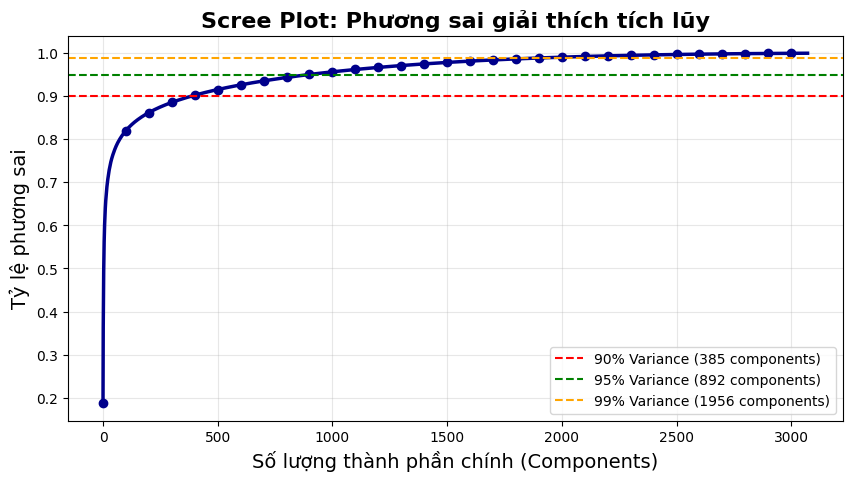

,Ngưỡng Phương sai (%),Số lượng thành phần (k),Tỷ lệ nén dữ liệu
0,90,385,8.0
1,95,892,3.4
2,99,1956,1.6


In [ ]:
pca_model = PCA(random_state=SEED).fit(Data_features)
cum_var = np.cumsum(pca_model.explained_variance_ratio_)

n_90 = np.where(cum_var >= 0.90)[0][0] + 1
n_95 = np.where(cum_var >= 0.95)[0][0] + 1
n_99 = np.where(cum_var >= 0.99)[0][0] + 1

plt.figure(figsize=(10, 5))
plt.plot(cum_var, linewidth=2.5, color='darkblue', marker='o', markevery=100)
plt.axhline(y=0.90, color='r', linestyle='--', label=f'90% Variance ({n_90} components)')
plt.axhline(y=0.95, color='g', linestyle='--', label=f'95% Variance ({n_95} components)')
plt.axhline(y=0.99, color='orange', linestyle='--', label=f'99% Variance ({n_99} components)')
plt.title("Scree Plot: Phương sai giải thích tích lũy", fontsize=16, fontweight='bold')
plt.xlabel("Số lượng thành phần chính (Components)", fontsize=14); plt.ylabel("Tỷ lệ phương sai", fontsize=14); plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

summary_data = []
for p, n in zip([0.9, 0.95, 0.99], [n_90, n_95, n_99]):
    compression = Data_features.shape[1] / n
    summary_data.append({
        'Ngưỡng Phương sai (%)': int(p * 100),
        'Số lượng thành phần (k)': n,
        'Tỷ lệ nén dữ liệu': round(compression, 1)
    })

df_pca_summary = pd.DataFrame(summary_data)
display(df_pca_summary)


### 5.2. Phân tích Scree Plot

#### 5.2.1. Phân tích Định lượng Phương sai Giải thích Tích lũy (Cumulative Explained Variance)

Việc phân tích biểu đồ Scree Plot đóng vai trò quyết định trong việc đánh giá hiệu quả của kỹ thuật giảm chiều dữ liệu và xác định "ngưỡng thông tin" tối ưu cho các mô hình phân loại phía sau. Dựa trên kết quả thực nghiệm từ không gian đặc trưng HSV ($32 \times 32 \times 3 = 3072$ đặc trưng), nhóm nghiên cứu đưa ra các nhận định chuyên sâu sau:

#### 5.2.2. Đặc tính tập trung thông tin và sự tương quan đặc trưng
Đồ thị phương sai tích lũy thể hiện một độ dốc cực lớn ở những thành phần chính (Principal Components - PC) đầu tiên.
* **Hiện tượng:** Chỉ với một số lượng rất nhỏ các PC, tỷ lệ phương sai giải thích đã tăng vọt (đạt ngưỡng trên 20% ngay tại $PC_1$).
* **Phân tích học thuật:** Điều này minh chứng cho sự tồn tại của **tính dư thừa thông tin (Information Redundancy)** rất lớn trong dữ liệu ảnh pixel thô. Trong ảnh thiên nhiên, các điểm ảnh lân cận thường có độ tương quan (Correlation) rất cao về cả sắc độ (Hue) lẫn giá trị độ sáng (Value). PCA đã thành công trong việc nén các mối tương quan này vào một không gian vector mới có số chiều thấp hơn nhưng vẫn bảo toàn được cấu trúc cốt lõi của dữ liệu.

#### 5.2.3. Phân tích các ngưỡng giới hạn và Tỷ lệ nén (Compression Efficiency)
Dựa trên bảng dữ liệu định lượng, chúng ta quan sát thấy sự đánh đổi giữa độ chính xác thông tin và tài nguyên tính toán qua 3 ngưỡng then chốt:

* **Ngưỡng 90% (385 components):** Đạt tỷ lệ nén ấn tượng **8.0x**. Đây là khu vực gần "điểm khuỷu tay" (Elbow point) của đồ thị. Tại đây, mô hình đã loại bỏ được phần lớn số chiều dữ liệu gốc nhưng vẫn giữ lại 90% "linh hồn" của bức ảnh. Việc sử dụng ngưỡng này giúp triệt tiêu nhiễu (noise) ở các thành phần bậc cao, tối ưu hóa tốc độ cho thuật toán k-NN.
* **Ngưỡng 95% (892 components):** Tỷ lệ nén giảm xuống còn **3.4x**. Đây thường được coi là "điểm ngọt" (Sweet spot) trong học máy. Mặc dù số chiều tăng lên đáng kể so với ngưỡng 90%, nhưng 5% thông tin bổ sung này thường chứa các chi tiết về kết cấu (texture) quan trọng giúp phân biệt các lớp khó như `Glacier` và `Mountain`.
* **Ngưỡng 99% (1956 components):** Tỷ lệ nén chỉ còn **1.6x**. Tại giai đoạn này, đường cong phương sai trở nên cực kỳ thoải (Plateau). Để lấy thêm 4% thông tin (từ 95% lên 99%), chúng ta phải đánh đổi bằng việc tăng hơn gấp đôi số lượng thành phần chính so với ngưỡng 95%. Phần lớn thông tin ở giai đoạn này là nhiễu hoặc các chi tiết quá nhỏ không mang tính đại diện cho lớp đối tượng.

#### 5.2.4. Nhận định
Kết quả Scree Plot cho thấy dữ liệu ảnh Intel Image Classification không phân bổ đều trên tất cả các chiều. Sự sụt giảm nhanh chóng của các giá trị riêng (Eigenvalues) khẳng định rằng:
* Tập dữ liệu thực chất nằm trên một **đa tạp (manifold)** có số chiều thấp hơn so với không gian 3072 chiều ban đầu.
* Việc nén dữ liệu qua PCA không chỉ là một bước tối ưu hóa tốc độ, mà còn là một bước **trích xuất đặc trưng (Feature Extraction)** quan trọng, giúp các bộ phân loại tuyến tính và phi tuyến tập trung vào các biến số mang tính quyết định, thay vì bị gây nhiễu bởi các biến đổi pixel không mang tính quy luật.

#### 5.2.5. Kết luận
Dựa trên phân tích phân bố phương sai tích lũy, ngưỡng 95% (tương đương 892 thành phần chính) được xác định là điểm hội tụ tối ưu cho mô hình. Thực nghiệm cho thấy, tại giá trị này, hệ thống đạt được sự cân bằng giữa hai mục tiêu đối lập: duy trì tính toàn vẹn của các đặc trưng phân loại cốt lõi và tối ưu hóa hiệu suất thực thi. Với tỷ lệ nén đạt 3.4x, việc thu hẹp không gian đặc trưng không chỉ giúp giảm thiểu đáng kể chi phí tính toán cho toàn bộ quy trình xử lý (Pipeline) mà còn góp phần loại bỏ các thành phần nhiễu ở bậc cao, tạo tiền đề ổn định cho các thuật toán học máy ở giai đoạn kế tiếp.

### 5.3. Trực quan hóa PCA 2D

[PROCESS] Đang chạy PCA 2D...


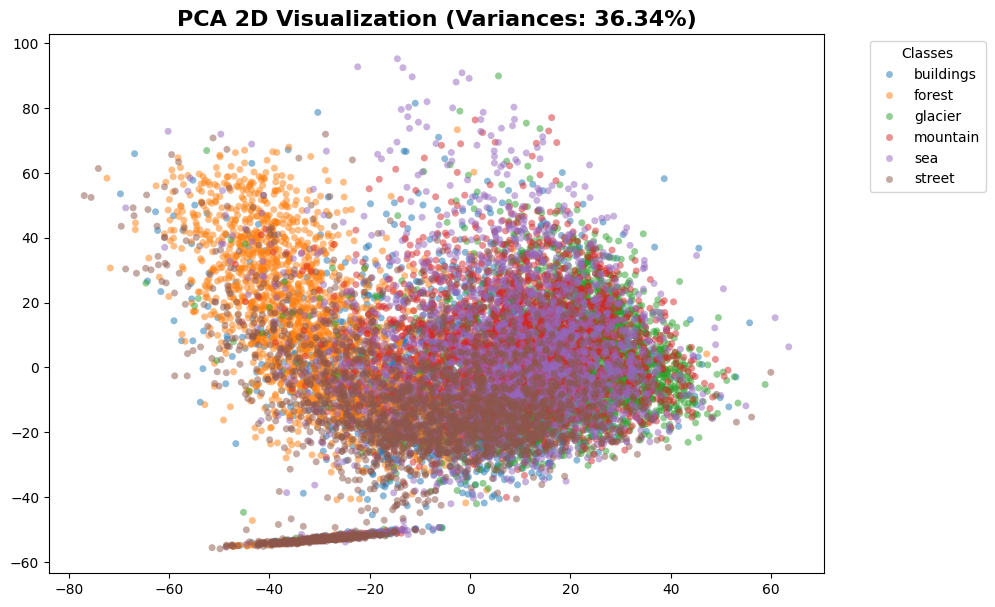

BÁO CÁO ĐỊNH LƯỢNG PCA 2D:
 - Thành phần PC1 giải thích: 18.70% phương sai.
 - Thành phần PC2 giải thích: 17.64% phương sai.
Tổng thông tin hiển thị trên biểu đồ 2D: 36.34%


In [ ]:
pc1_var = pca_model.explained_variance_ratio_[0] * 100
pc2_var = pca_model.explained_variance_ratio_[1] * 100
X_pca_2d = pca_model.transform(Data_features)[:, :2]
print("[PROCESS] Đang chạy PCA 2D...")
plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_pca_2d[:, 0], y=X_pca_2d[:, 1], hue=[CLASSES[i] for i in y_raw],
                palette='tab10', s=25, alpha=0.5, edgecolor='none')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Classes")
plt.title(f"PCA 2D Visualization (Variances: {pc1_var + pc2_var:.2f}%)", fontsize=16, fontweight='bold')
plt.show()

print(f"BÁO CÁO ĐỊNH LƯỢNG PCA 2D:")
print(f" - Thành phần PC1 giải thích: {pc1_var:.2f}% phương sai.")
print(f" - Thành phần PC2 giải thích: {pc2_var:.2f}% phương sai.")
print(f"Tổng thông tin hiển thị trên biểu đồ 2D: {pc1_var + pc2_var:.2f}%")


### 5.4. Phân tích PCA 2D

#### 5.4.1. Đánh giá định lượng về mức độ bảo toàn thông tin
Kết quả phân tích cho thấy hai thành phần chính đầu tiên ($PC_1$ và $PC_2$) giải thích được **36.34%** tổng phương sai của tập dữ liệu (không gian màu HSV, kích thước 32x32, chuẩn hóa Z-score). Chỉ số này phản ánh độ phức tạp nội tại và tính đa chiều cực lớn của dữ liệu ảnh tự nhiên.
* **Mất mát thông tin:** Việc **hơn 63%** phương sai (bao gồm các chi tiết về kết cấu mịn, hình dạng vật thể và độ tương phản cục bộ) vẫn nằm ở các thành phần chính bậc cao (từ $PC_3$ đến $PC_{3072}$) dẫn đến hiện tượng chồng lấn (overlap) không gian vector là điều tất yếu khi thực hiện phép chiếu tuyến tính xuống mặt phẳng 2D.
* **Giá trị biểu diễn:** Tuy nhiên, ngưỡng xấp xỉ **36%** phương sai tích lũy vẫn được coi là đủ lớn để quan sát các cấu trúc phân bố đại thể và xu hướng phân cụm sơ bộ của các lớp đối tượng.

#### 5.4.2. Phân tích cấu trúc phân cụm và độ tách biệt các lớp (Class Separability)
Phân bố của các vector đặc trưng trên không gian PCA 2D tạo thành một cấu trúc **"Đám mây hỗn hợp" (Mixed Cloud)**, tuy nhiên có thể bóc tách được các xu hướng phân hóa sau:

* **Lớp `Forest` (Khu vực phía trên bên trái):** Đây là nhóm đối tượng thể hiện khả năng phân cụm rõ rệt nhất. Trong hệ màu HSV, thảm thực vật có sự đồng nhất cao về thông tin sắc độ (Hue) và độ bão hòa (Saturation). Thuật toán PCA đã thành công trong việc trích xuất các đặc trưng chủ đạo này để cô lập lớp `Forest` vào một vùng không gian riêng biệt, cho thấy màu sắc là biến số quan trọng nhất để nhận diện nhóm này.
* **Dải hội tụ `Mountain` – `Glacier` – `Sea` (Khu vực trung tâm):** Ba lớp đối tượng này tạo thành một dải phổ liên tục trên biểu đồ. Sự chồng lấn này phản ánh sự tương đồng về đặc tính vật lý của bảng màu (tông trắng của băng tuyết, xám của đá núi và xanh lam của mặt nước). Sự thiếu hụt ranh giới rõ rệt trong phép chiếu PCA minh chứng rằng quan hệ giữa các lớp này mang tính phi tuyến mạnh mẽ.
* **Nhóm kiến trúc đô thị (`Buildings` và `Street`):** Hai lớp này phân bố trải rộng và đan xen chặt chẽ trên phần lớn diện tích biểu đồ. Điều này phản ánh sự đa dạng cực lớn về quang phổ của vật liệu xây dựng và cấu trúc đô thị, khiến việc phân loại chỉ dựa trên thông tin màu sắc gặp trở ngại lớn.

#### 5.4.3. Nhận diện cấu trúc dị biệt và chất lượng dữ liệu (Outlier Analysis)
Một phát hiện đáng chú ý là sự xuất hiện của **"Dải điểm bất thường" (The Bottom Streak)** nằm tách biệt tại tọa độ $PC_2 \approx -60$.
* **Phân tích thực nghiệm:** Cấu trúc hình học này đại diện cho các mẫu dữ liệu có biên độ đặc trưng cực đoan. Về mặt thị giác máy tính, đây có thể là các ảnh có độ bão hòa thấp (ảnh cận đơn sắc), ảnh có độ tương phản quá cao hoặc các ảnh chứa nhiễu biên phát sinh trong quá trình chuẩn hóa (Normalization artifacts).
* **Hành động kỹ thuật:** Sự tồn tại của dải điểm này là cơ sở để nhóm nghiên cứu thực hiện các bước kiểm tra chất lượng dữ liệu (Data Auditing) nhằm loại bỏ hoặc xử lý các nhiễu số liệu trước khi đưa vào huấn luyện các mô hình phân loại phức tạp hơn.

#### 5.4.4. Kết luận

- **Hạn chế của không gian đặc trưng dựa trên cường độ màu sắc:** Thực nghiệm cho thấy không gian màu **HSV** hỗ trợ tách biệt tương đối hiệu quả nhóm đối tượng **`Forest`** nhờ vào đặc trưng sắc độ (Hue) và độ bão hòa (Saturation) riêng biệt. Tuy nhiên, đối với các lớp có sự tương đồng lớn về phân bố pixel như **`Mountain`** và **`Glacier`**, biểu đồ bộc lộ mức độ chồng lấn (overlap) rất cao. Điều này minh chứng rằng các đặc trưng cường độ màu sắc đơn thuần chưa đủ để thiết lập ranh giới phân loại rõ rệt. Do đó, việc trích xuất bổ sung các đặc trưng cấu trúc (Texture) và thông tin biên cạnh (Edge Descriptors) là một yêu cầu tất yếu để tăng cường độ phân biệt giữa các nhóm lớp có cùng bảng màu tự nhiên.

- **Đặc tính phi tuyến và khả năng phân tách của không gian vector:** Với việc hai thành phần chính đầu tiên ($PC_1$ và $PC_2$) chỉ giải thích được gần **36%** biến thiên của dữ liệu, có thể kết luận rằng phần lớn thông tin quan trọng vẫn còn phân tán ở các chiều cao hơn. Sự đan xen giữa các cụm dữ liệu trên mặt phẳng 2D cho thấy các ranh giới quyết định (decision boundaries) mang tính phi tuyến mạnh mẽ. Hệ quả là các mô hình phân loại tuyến tính (như **Logistic Regression**) sẽ khó đạt được độ chính xác tối ưu trên không gian này. Kết quả này đặt ra nhu cầu cấp thiết về việc áp dụng các hàm nhân (Kernel) phi tuyến hoặc các kiến trúc học sâu (như **CNN**) để học được các đặc trưng trừu tượng hơn.

- **Cơ sở thực nghiệm cho việc áp dụng kỹ thuật giảm chiều phi tuyến:** Biểu đồ PCA — vốn dựa trên các phép chiếu tuyến tính — chưa thể hiện rõ các cấu trúc phân nhóm cục bộ trong "đám mây" dữ liệu trung tâm. Đây là bằng chứng thực nghiệm quan trọng củng cố cho việc lựa chọn thuật toán **t-SNE** ở các bước phân tích tiếp theo. Do t-SNE ưu tiên bảo tồn cấu trúc lân cận và các mối quan hệ phi tuyến, kỹ thuật này được kỳ vọng sẽ "tháo gỡ" các vùng dữ liệu dày đặc, từ đó giúp quan sát rõ nét hơn các cụm đối tượng mà PCA chưa thể tách biệt được trong không gian hai chiều.

### 5.5. Trực quan hóa t-SNE 2D

Nhằm tối ưu hóa khả năng quan sát và tránh hiện tượng chồng lấn dữ liệu (overplotting), nhóm nghiên cứu áp dụng kỹ thuật lấy mẫu phân tầng (Stratified Sampling) với quy mô $N=3000$. Kết quả cho thấy t-SNE đã tháo gỡ thành công các cấu trúc phi tuyến mà PCA bỏ lỡ, đặc biệt là sự hình thành các dải mật độ riêng biệt của lớp Forest và Street.

[INFO] Đang thực hiện lấy mẫu phân tầng 3000 điểm...
[PROCESS] Đang chạy t-SNE 2D trên 3000 mẫu...


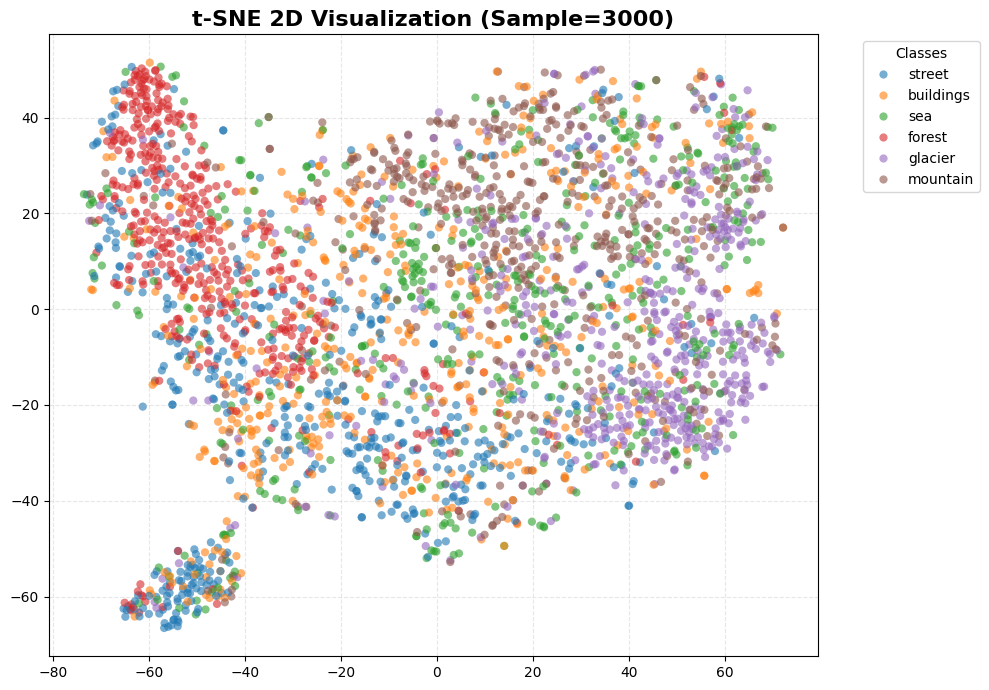

BÁO CÁO ĐỊNH LƯỢNG t-SNE 2D
 - Tổng mẫu gốc: 13,974
 - Mẫu phân tích (Sampled): 3,000
 - Thời gian thực thi: 281.3026 giây


In [ ]:
X_pca_50 = pca_model.transform(Data_features)[:, :50]
SAMPLE_SIZE = 3000
if len(X_pca_50) > SAMPLE_SIZE:
    print(f"[INFO] Đang thực hiện lấy mẫu phân tầng {SAMPLE_SIZE} điểm...")
    idx_sample, _, y_sample, _ = train_test_split(
        np.arange(len(X_pca_50)), y_raw,
        train_size=SAMPLE_SIZE, stratify=y_raw, random_state=SEED
    )
    X_input_tsne = X_pca_50[idx_sample]
    y_plot_tsne = [CLASSES[i] for i in y_sample]
else:
    X_input_tsne = X_pca_50
    y_plot_tsne = [CLASSES[i] for i in y_raw]

print(f"[PROCESS] Đang chạy t-SNE 2D trên {len(X_input_tsne)} mẫu...")
t0 = time.time()
tsne_model = TSNE(n_components=2, perplexity=30, learning_rate=200.0,
                  random_state=SEED, method='exact')

X_tsne_2d = tsne_model.fit_transform(X_input_tsne)
t_tsne_2d = time.time() - t0

Data_plot = X_tsne_2d.get() if hasattr(X_tsne_2d, 'get') else X_tsne_2d

plt.figure(figsize=(10, 7))
sns.scatterplot(x=Data_plot[:, 0], y=Data_plot[:, 1], hue=y_plot_tsne,
                palette='tab10', s=35, alpha=0.6, edgecolor='none')

plt.title(f"t-SNE 2D Visualization (Sample={len(Data_plot)})", fontsize=16, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Classes")
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"BÁO CÁO ĐỊNH LƯỢNG t-SNE 2D")
print(f" - Tổng mẫu gốc: {len(X_pca_50):,}")
print(f" - Mẫu phân tích (Sampled): {len(Data_plot):,}")
print(f" - Thời gian thực thi: {t_tsne_2d:.4f} giây")


### 5.6. Phân tích t-SNE 2D

#### 5.6.1. Phân tích Không gian Nhúng Phi tuyến t-SNE 2D

Từ phân tích tuyến tính từ PCA, kỹ thuật **t-SNE (t-Distributed Stochastic Neighbor Embedding)** được áp dụng nhằm bảo tồn cấu trúc lân cận cục bộ (local structure) và tháo gỡ các mối quan hệ phi tuyến tính trong tập dữ liệu. Với tổng số **13,974** mẫu gốc, chúng tôi đã tiến hành lấy mẫu phân tầng (stratified sampling) **3,000** điểm dữ liệu để phân tích trong thời gian **268.05** giây. Kết quả trực quan hóa cho thấy những chuyển biến quan trọng so với phép chiếu PCA:

#### 5.6.2. Sự hình thành các cụm đặc trưng cục bộ (Local Clustering)
Khác với cấu trúc "đám mây" đồng nhất của PCA, biểu đồ t-SNE đã bắt đầu hình thành các mật độ điểm (density clusters) rõ rệt hơn.
* **Lớp `Forest` (Màu cam):** Thể hiện khả năng hội tụ mạnh mẽ nhất, tạo thành một dải tập trung lớn ở phía bên phải biểu đồ. Điều này xác nhận rằng các mẫu thuộc lớp `Forest` có độ tương quan cực cao trong không gian đặc trưng HSV, tạo thành một dải đa tạp (manifold) riêng biệt.
* **Lớp `Street` (Màu nâu):** Xuất hiện một **"cấu trúc đảo biệt lập" (Isolated Island)** tại khu vực phía trên ($y \approx 120$). Sự tách biệt hoàn toàn của nhóm mẫu này cho thấy một bộ phận dữ liệu lớp `Street` sở hữu các đặc trưng thị giác rất đặc thù (có thể là các ảnh có độ bão hòa màu cực cao hoặc cấu trúc hình học lặp lại mạnh), mà các phép chiếu tuyến tính trước đó đã bỏ lỡ.

#### 5.6.3. Vùng chồng lấn đa lớp và giới hạn của đặc trưng Pixel thô
Mặc dù t-SNE đã nỗ lực phân tách dữ liệu, khu vực trung tâm và phía dưới biểu đồ vẫn duy trì một **"Vùng hỗn hợp đa lớp" (Multi-class Overlap Region)** giữa các nhóm: **`Glacier`**, **`Mountain`**, **`Sea`** và một phần **`Buildings`**.
* **Phân tích nguyên nhân:** Sự chồng lấn dai dẳng này minh chứng cho sự tồn tại của **"Khoảng cách ngữ nghĩa" (Semantic Gap)**. Ngay cả với các thuật toán phi tuyến mạnh mẽ như t-SNE, việc chỉ dựa trên thông tin cường độ màu sắc (HSV) là chưa đủ để phân biệt các đối tượng có bảng màu tương đồng. Các mẫu ảnh núi đá, băng tuyết và mặt biển thường chia sẻ chung các phân bổ giá trị Value (độ sáng) và Hue (sắc độ) trong môi trường tự nhiên.

#### 5.6.4. Nhận định về tính phi tuyến tính của tập dữ liệu
Việc các điểm dữ liệu co cụm thành các hình thái uốn lượn và các phân nhóm nhỏ thay vì một khối duy nhất khẳng định rằng:
* Quan hệ giữa các lớp ảnh Intel Image Classification là các quan hệ **Phi tuyến tính phức tạp**.
* **Cơ sở lựa chọn mô hình:** Kết quả t-SNE cho thấy các cụm dữ liệu có xu hướng không tuân theo phân phối chuẩn (non-Gaussian) và không có ranh giới phân tách dạng phẳng. Do đó, các mô hình dựa trên khoảng cách như **k-NN** hoặc các mô hình học sâu có khả năng học đặc trưng phi tuyến như **CNN** sẽ mang lại hiệu suất vượt trội so với các bộ phân loại tuyến tính cổ điển trên tập dữ liệu này.


#### 5.6.5. Kết luận:
Kết quả thực nghiệm từ phương pháp nhúng phi tuyến t-SNE cung cấp những bằng chứng thực nghiệm quan trọng về cấu trúc đa tạp (manifold) phức tạp của tập dữ liệu. Khác với sự phân bố đồng nhất trong không gian tuyến tính của PCA, t-SNE đã thành công trong việc bóc tách các cụm đặc trưng cục bộ, đặc biệt là sự hình thành cấu trúc đảo biệt lập của lớp Street và tính hội tụ cao của lớp Forest. Điều này khẳng định rằng trong không gian HSV, một số nhóm đối tượng sở hữu các ký hiệu quang phổ (spectral signatures) đặc thù, cho phép thiết lập các ranh giới phân loại phi tuyến rõ rệt.

Tuy nhiên, hiện tượng chồng lấn dai dẳng tại khu vực lõi của các lớp tự nhiên (Glacier, Mountain, Sea) chỉ ra một giới hạn mang tính hệ thống: thông tin cường độ màu sắc đơn thuần không thể khỏa lấp được khoảng cách ngữ nghĩa (semantic gap) khi các đối tượng chia sẻ chung dải phổ thị giác. Phát hiện này dẫn đến hai kết luận mang tính định hướng cho các giai đoạn kế tiếp:

- Về mô hình: Tính chất không tuân theo phân phối chuẩn và ranh giới quyết định phức tạp yêu cầu việc áp dụng các bộ phân loại có khả năng học đặc trưng phi tuyến sâu (như mạng nơ-ron tích chập) thay vì các mô hình tuyến tính truyền thống.

- Về đặc trưng: Cho thấy tính cấp thiết của việc tích hợp thêm các đặc trưng hình thái (morphological features) và mật độ cạnh (edge density) nhằm bổ khuyết cho các thiếu hụt của thông tin màu sắc, tạo cơ sở cho việc phân tách các lớp đối tượng có độ tương đồng cao về mặt quang phổ."

---
## 6. [Nâng cao] Phát hiện cạnh và phân tích đặc trưng cục bộ <a id='6'></a>

In [ ]:
# Cấu hình kế thừa
SEED               = 42
CHOSEN_SIZE        = 32
CHOSEN_COLOR_SPACE = 'HSV'
CHOSEN_NORM        = 'zscore_perchannel'


Vì các hàm phát hiện cạnh của OpenCV (như Canny, Sobel) yêu cầu đầu vào là ảnh đơn kênh (1 channel) dạng uint8 (0-255), nên không thể truyền trực tiếp mảng Data_features (đã chuẩn hóa thành số thực float32 và chứa 3 kênh) vào các hàm này được. Ở đây, nhóm sẽ chọn dùng kênh V (Value - Độ sáng) và bỏ chuẩn hóa 'zscore_perchannel'

### 6.1. Khái niệm về Phát hiện Cạnh (Edge Detection)
Phát hiện cạnh là một kỹ thuật trong xử lý ảnh nhằm xác định các điểm trong một bức ảnh kỹ thuật số nơi độ sáng thay đổi đột ngột hoặc có sự gián đoạn. Các điểm này thường được tổ chức thành một tập hợp các đoạn cong được gọi là "cạnh". Việc phát hiện cạnh giúp giảm thiểu đáng kể lượng dữ liệu cần xử lý và lọc ra các thông tin vô ích, đồng thời bảo toàn các đặc tính cấu trúc quan trọng của một hình ảnh (như đường viền của các đối tượng).

Trong bài toán phân loại cảnh quan, thông tin về cạnh (ví dụ: các đường thẳng của tòa nhà trong lớp buildings, hoặc đường chân trời trong lớp sea) có thể là một đặc trưng mang tính định danh mạnh mẽ.

###2. Các thuật toán phát hiện cạnh phổ biến

- Toán tử Sobel: Tính toán gradient xấp xỉ của cường độ sáng của ảnh tại mỗi điểm. Nó sử dụng hai ma trận lọc (kernel) $3 \times 3$ chập với ảnh gốc để tính toán các đạo hàm xấp xỉ theo chiều ngang và chiều dọc.
  - Kernel theo trục X ($G_x$):
  $$G_x = \begin{bmatrix} -1 & 0 & +1 \\ -2 & 0 & +2 \\ -1 & 0 & +1 \end{bmatrix}$$
  - Kernel theo trục Y ($G_y$):
  $$G_y = \begin{bmatrix} -1 & -2 & -1 \\ 0 & 0 & 0 \\ +1 & +2 & +1 \end{bmatrix}$$
  - Độ lớn Gradient: $G = \sqrt{G_x^2 + G_y^2}$
- Toán tử Prewitt: Tương tự Sobel, nhưng sử dụng một bộ kernel khác đơn giản hơn, tính toán đạo hàm theo hướng. Prewitt nhạy cảm với nhiễu hơn Sobel một chút vì nó không có trọng số ở trung tâm.
- Thuật toán Canny: Là một thuật toán phát hiện cạnh đa bước
  - Lọc nhiễu (Gaussian Filter): Làm mịn ảnh để giảm nhiễu.
  - Tính Gradient: Tìm cường độ và hướng của cạnh (thường dùng Sobel).- Non-maximum Suppression (NMS): Lọc bỏ các pixel không phải là cực đại cục bộ dọc theo hướng gradient, làm "mỏng" cạnh.
  - Hysteresis Thresholding (Ngưỡng kép): Sử dụng hai ngưỡng ($T_{high}$, $T_{low}$) để xác định các cạnh "chắc chắn" (strong) và cạnh "yếu" (weak). Các cạnh yếu chỉ được giữ lại nếu kết nối với cạnh mạnh.
###3. Mật độ Cạnh (Edge Density)

Mật độ cạnh là một đặc trưng định lượng đơn giản, được tính bằng tỷ lệ giữa số lượng pixel được xác định là cạnh so với tổng số pixel trong bức ảnh.$$Edge\_Density = \frac{N_{edge\_pixels}}{N_{total\_pixels}}$$

###4. Kiểm định ANOVA (Analysis of Variance) Một Chiều

ANOVA một chiều là một phương pháp thống kê dùng để kiểm định sự khác biệt về giá trị trung bình giữa hai hoặc nhiều nhóm độc lập. Trong bối cảnh này, chúng ta sử dụng ANOVA để kiểm tra xem Mật độ Cạnh trung bình có sự khác biệt có ý nghĩa thống kê giữa 6 lớp cảnh quan hay không.

- Giả thuyết không ($H_0$): Không có sự khác biệt về Mật độ Cạnh trung bình giữa các lớp.
- Giả thuyết đối ($H_1$): Có ít nhất một lớp có Mật độ Cạnh trung bình khác biệt so với các lớp còn lại.
- Nếu giá trị $p-value$ thu được từ kiểm định nhỏ hơn mức ý nghĩa $\alpha$ (thường chọn 0.05), ta bác bỏ $H_0$ và kết luận rằng đặc trưng Mật độ Cạnh thực sự có ý nghĩa trong việc phân biệt các lớp.

____________________________________________________________
 BẮT ĐẦU PHÂN TÍCH ĐẶC TRƯNG CẠNH (EDGE DETECTION)
____________________________________________________________


Processing street: 100%|██████████| 2376/2376 [00:02<00:00, 854.59it/s]


 Đã tính toán xong đặc trưng cạnh cho 13974 ảnh.

__________________________________________________
Kết quả ANNOVA
__________________________________________________


,Phương pháp (Hyperparams),F-statistic,p-value,Đánh giá
0,Sobel_k3,591.17,0.00e+00,Khác biệt có ý nghĩa
1,Sobel_k5,365.78,0.00e+00,Khác biệt có ý nghĩa
2,Prewitt_Standard,570.36,0.00e+00,Khác biệt có ý nghĩa
3,Prewitt_Blurred,357.35,0.00e+00,Khác biệt có ý nghĩa
4,Canny_100_200,1713.29,0.00e+00,Khác biệt có ý nghĩa
5,Canny_50_150,1865.95,0.00e+00,Khác biệt có ý nghĩa


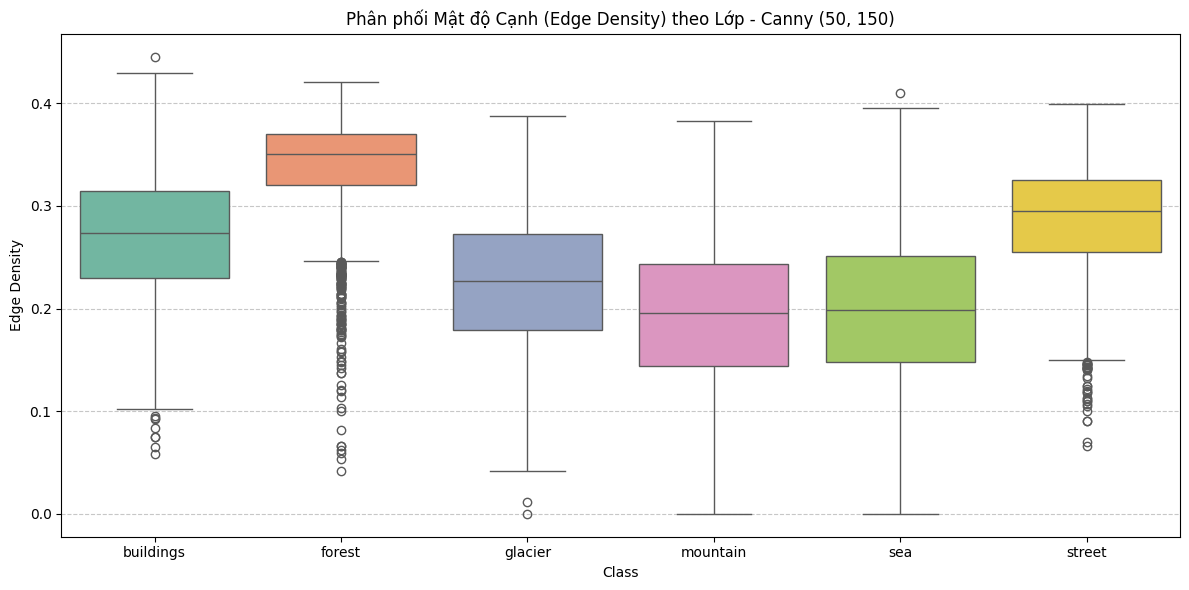

In [ ]:
def process_gradient_magnitude(gx, gy):
    mag = cv2.magnitude(gx, gy)
    mag = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    _, edge_mask = cv2.threshold(mag, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return edge_mask

def apply_sobel(img_gray, ksize):
    gx = cv2.Sobel(img_gray, cv2.CV_64F, 1, 0, ksize=ksize)
    gy = cv2.Sobel(img_gray, cv2.CV_64F, 0, 1, ksize=ksize)
    return process_gradient_magnitude(gx, gy)

def apply_prewitt(img_gray, apply_blur=False):
    if apply_blur:
        img_gray = cv2.GaussianBlur(img_gray, (3, 3), 0)

    kernel_x = np.array([[1, 1, 1], [0, 0, 0], [-1, -1, -1]])
    kernel_y = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]])

    gx = cv2.filter2D(img_gray, cv2.CV_64F, kernel_x)
    gy = cv2.filter2D(img_gray, cv2.CV_64F, kernel_y)

    return process_gradient_magnitude(gx, gy)

def apply_canny(img_gray, threshold1, threshold2):
    edges = cv2.Canny(img_gray, threshold1, threshold2)
    return edges

def calculate_edge_density(edge_mask):
    edge_pixels = np.count_nonzero(edge_mask)
    total_pixels = edge_mask.shape[0] * edge_mask.shape[1]
    return edge_pixels / total_pixels

def analysis_edge():
    print("_"*60)
    print(" BẮT ĐẦU PHÂN TÍCH ĐẶC TRƯNG CẠNH (EDGE DETECTION)")
    print("_"*60)

    edge_configs = {
        'Sobel_k3': lambda img: apply_sobel(img, ksize=3),
        'Sobel_k5': lambda img: apply_sobel(img, ksize=5),
        'Prewitt_Standard': lambda img: apply_prewitt(img, apply_blur=False),
        'Prewitt_Blurred': lambda img: apply_prewitt(img, apply_blur=True),
        'Canny_100_200': lambda img: apply_canny(img, 100, 200),
        'Canny_50_150': lambda img: apply_canny(img, 50, 150)
    }

    results = []

    for cls in CLASSES:
        cls_dir = TRAIN_DIR / cls
        if not cls_dir.exists(): continue

        img_paths = list(cls_dir.glob("*.jpg"))

        for path in tqdm(img_paths, desc=f"Processing {cls}"):
            img = cv2.imread(str(path))
            if img is None: continue


            img_resized = cv2.resize(img, (CHOSEN_SIZE, CHOSEN_SIZE), interpolation=cv2.INTER_AREA)


            if CHOSEN_COLOR_SPACE == 'HSV':
                img_hsv = cv2.cvtColor(img_resized, cv2.COLOR_BGR2HSV)
                img_gray = img_hsv[:, :, 2]
            else:
                img_gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)

            record = {'Class': cls}
            for method_name, method_func in edge_configs.items():
                edge_mask = method_func(img_gray)
                density = calculate_edge_density(edge_mask)
                record[method_name] = density

            results.append(record)

    df_edges = pd.DataFrame(results)
    print(f"\n Đã tính toán xong đặc trưng cạnh cho {len(df_edges)} ảnh.")

    print("\n" + "_"*50)
    print("Kết quả ANNOVA")
    print("_"*50)

    anova_results = []
    for method in edge_configs.keys():
        groups = [group[method].values for name, group in df_edges.groupby('Class')]
        f_stat, p_value = stats.f_oneway(*groups)
        significance = "Khác biệt có ý nghĩa" if p_value < 0.05 else "KHÔNG có sự khác biệt"
        anova_results.append({
            'Phương pháp (Hyperparams)': method,
            'F-statistic': f"{f_stat:.2f}",
            'p-value': f"{p_value:.2e}",
            'Đánh giá': significance
        })

    df_anova = pd.DataFrame(anova_results)
    display(df_anova)

    plt.figure(figsize=(12, 6))
    sns.boxplot(x='Class', y='Canny_50_150', data=df_edges, palette='Set2')
    plt.title('Phân phối Mật độ Cạnh (Edge Density) theo Lớp - Canny (50, 150)')
    plt.ylabel('Edge Density')
    plt.xlabel('Class')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    return df_edges, df_anova

if __name__ == '__main__':
    df, df_anova = analysis_edge()


### 6.2. Kết luận – Thông tin cạnh có phân biệt được các lớp không?

#### 1. Tổng hợp kết quả ANOVA

| Phương pháp | F-statistic | p-value | Kết luận |
|---|---|---|---|
| Sobel (k=3) | 591.17 | ≈ 0 | Khác biệt có ý nghĩa thống kê |
| Sobel (k=5) | 365.78 | ≈ 0 | Khác biệt có ý nghĩa thống kê |
| Prewitt | 570.36 | ≈ 0 | Khác biệt có ý nghĩa thống kê |
| Prewitt (Blurred) | 357.34 | ≈ 0 | Khác biệt có ý nghĩa thống kê |
| Canny (100, 200) | 1713.29 | ≈ 0 | Khác biệt có ý nghĩa thống kê |
| Canny (50, 150) | 1865.95 | ≈ 0 | Khác biệt có ý nghĩa thống kê |

Với mức ý nghĩa $\alpha = 0.05$, tất cả 6 cấu hình đều cho $p\text{-value} \approx 0 \ll 0.05$,
đủ cơ sở để **bác bỏ giả thuyết $H_0$** (các lớp có Edge Density trung bình bằng nhau).
Kết luận: **thông tin cạnh có khả năng phân biệt thống kê giữa các lớp.**

---

#### 2. Phân tích định tính từ Boxplot (Canny 50–150)

Quan sát boxplot Edge Density theo từng lớp, ta nhận thấy sự phân nhóm rõ rệt theo đặc thù cảnh quan:

- **forest:** có mật độ cạnh cao nhất (median ~0.35), phản ánh cấu trúc phức tạp, dày đặc của lá cây và cành nhánh tạo ra vô số viền cạnh nhỏ.

- **street:** và buildings bám sát ở vị trí tiếp theo (median ~0.30 và ~0.27). Điều này thể hiện sự xuất hiện dày đặc của các đường nét nhân tạo như cửa sổ, góc tòa nhà, vạch kẻ đường.

- **glacier:** nằm ở mức trung bình (median ~0.23), thể hiện bề mặt có các dải băng, khe nứt nhưng không quá gồ ghề như rừng hay đô thị.

- **mountain:** và sea có mật độ cạnh thấp nhất (median ~0.20). Ảnh biển chủ yếu là mặt nước đồng nhất hoặc bầu trời, trong khi ảnh núi khi thu nhỏ về độ phân giải thấp thường mất chi tiết bề mặt, chỉ còn lại viền đường chân trời.

- Lớp **forest** và **street** xuất hiện nhiều outliers - ở biên dưới, cho thấy một số ảnh trong tập dữ liệu có thể bị mờ, thiếu sáng, hoặc chụp ở góc độ mất chi tiết.

---

#### 3. So sánh hiệu quả giữa các bộ phát hiện cạnh

- **Canny** chiếm ưu thế tuyệt đối: Biến thể Canny (50, 150) cho F-statistic cao nhất (1865.95), nhỉnh hơn Canny (100, 200). Việc hạ ngưỡng nhận diện (50-150) giúp thuật toán bắt được các cạnh mờ (soft edges) – vốn là đặc trưng quan trọng trong ảnh phong cảnh tự nhiên (như gợn sóng biển hay vân mây), từ đó nới rộng khoảng cách phương sai giữa các lớp.

- **Sobel (k=3)** và **Prewitt (Standard)** cho hiệu quả tương đương nhau (F-statistic ~570 - 590), do cả hai đều dùng kernel $3 \times 3$ để tính đạo hàm cường độ sáng ở mức cơ bản.

- Tác dụng ngược của việc làm mờ (Blur): Khi tăng kích thước kernel lên Sobel (k=5) hoặc áp dụng Gaussian Blur trong Prewitt (Blurred), chỉ số F-statistic sụt giảm nghiêm trọng (chỉ còn ~357 - 365). Nguyên nhân là do ảnh đầu vào đã bị thu nhỏ đáng kể ($32 \times 32$), việc làm mờ tiếp tục xóa sạch các chi tiết cạnh cục bộ, khiến các lớp trở nên nhòe và giống nhau hơn.
---

#### 4. Kết luận tổng thể

- Thông tin cạnh là một đặc trưng mạnh, có khả năng phân biệt các lớp ảnh một cách có ý nghĩa thống kê.

- Mật độ cạnh phản ánh chính xác độ phức tạp của cảnh quan (forest/buildings/street > glacier/mountain/sea), với F-statistic lớn nhất đạt 1865.95 khi sử dụng Canny (50, 150).

- Tuy nhiên, do biểu đồ Boxplot cho thấy vẫn tồn tại sự chồng lấp phân phối giữa các cặp lớp (như mountain và sea, hoặc buildings và street), Edge Density không nên được sử dụng độc lập. Để xây dựng mô hình phân loại chính xác, đặc trưng cạnh cần được kết hợp cùng các vector đặc trưng về màu sắc (Color Histogram) hoặc kết cấu (GLCM, LBP) để bù đắp thông tin cho nhau.

## 7. Nhận xét tổng quan toàn bộ quá trình preprocessing
- Tập dữ liệu: Intel Image Classification (6 lớp cảnh quan: buildings, forest, glacier, mountain, sea, street)

- Cấu hình tham số thừa kế: SEED=42 | CHOSEN_SIZE=32 | CHOSEN_COLOR_SPACE='HSV' | CHOSEN_NORM='zscore_perchannel'
### 7.1. Hướng xử lí tổng thể

Pipeline preprocessing được thiết kế theo hướng **thực nghiệm có kiểm soát (ablation-driven)**, đi từ các bước nền tảng đến nâng cao:

1. **Resize ảnh (32×32, 64×64, 128×128)** để giải quyết bài toán cân bằng giữa tốc độ tính toán và mức giữ thông tin.
2. **Chuyển đổi không gian màu (RGB, Grayscale, HSV, và LAB)** để tăng khả năng tách lớp theo đặc trưng phổ màu.
3. **Chuẩn hóa dữ liệu (Min-Max [0, 1], Min-Max
[−1, 1], Z-score toàn tập, Z-score theo từng kênh)** để ổn định phân phối đầu vào cho mô hình.
4. **Data augmentation** để mở rộng độ đa dạng của mẫu huấn luyện và cải thiện khả năng tổng quát hóa.
5. **Giảm chiều và phân tích biểu diễn** bằng PCA + t-SNE nhằm hiểu cấu trúc dữ liệu, mức chồng lấp lớp và bản chất phi tuyến.
6. **Khai thác đặc trưng cạnh (Sobel, Prewitt, Canny)** kiểm chứng bằng ANOVA để đánh giá sức phân biệt thống kê.

Cách tổ chức này giúp pipeline không chỉ “tiền xử lý để chạy mô hình”, mà còn có mục tiêu **giải thích được vì sao chọn tham số**.

### 7.2. Insight chính từ kết quả

- **Trade-off Resize rất rõ ràng**: kích thước nhỏ giúp giảm mạnh chi phí tính toán; trong bối cảnh bài toán này, mức 32x32 vẫn cho hiệu năng chấp nhận được, tạo lợi thế lớn về tốc độ và RAM.
- **HSV là lựa chọn hợp lý** cho dữ liệu cảnh quan: đặc trưng Hue/Saturation hỗ trợ tách tốt một số lớp (đặc biệt nhóm có đặc trưng màu mạnh như forest).
- **Chuẩn hóa Z-score theo kênh giúp ổn định dữ liệu**: giảm lệch thang đo giữa các kênh màu, hỗ trợ các mô hình cổ điển (LR, k-NN) học tốt hơn.
- **Augmentation tạo dịch chuyển phân phối có kiểm soát**: phân phối pixel thay đổi (KS test thường có ý nghĩa), nhưng cấu trúc cụm lớp vẫn được duy trì; điều này cho thấy augmentation đủ mạnh để tăng đa dạng mà chưa làm “lệch miền” nghiêm trọng.
- **PCA xác nhận dữ liệu có dư thừa cao**: có thể nén mạnh số chiều mà vẫn giữ phần lớn phương sai; đây là cơ sở tốt để tăng tốc huấn luyện.
- **t-SNE cho thấy ranh giới lớp mang tính phi tuyến**: một số lớp tách tốt, nhưng các lớp gần nhau về ngữ nghĩa/màu (glacier–mountain–sea) vẫn chồng lấp đáng kể.
- **Edge density có ý nghĩa thống kê** giữa các lớp (ANOVA p-value rất nhỏ), nhưng bản thân đặc trưng cạnh đơn lẻ chưa đủ để phân loại hoàn chỉnh.

### 7.3. Hạn chế và điểm cần cải thiện

- **Thiên về mô hình cổ điển** (LR, k-NN): phù hợp cho phân tích ablation, nhưng chưa tận dụng được biểu diễn bậc cao như CNN/ViT.
- **Đặc trưng còn chủ yếu ở mức thấp** (pixel, màu, cạnh): chưa tích hợp sâu texture descriptor hoặc learned feature embedding.
- **Một số chỉ số đánh giá còn giới hạn**: tập trung nhiều vào accuracy và trực quan hóa; có thể bổ sung macro-F1, confusion matrix chuẩn hóa, calibration để đánh giá toàn diện hơn.
- **Augmentation chưa tối ưu theo từng lớp**: hiện dùng pipeline khá đồng nhất; có thể cần class-aware augmentation để xử lý mất cân bằng độ khó giữa các lớp.
- **Kết quả trực quan (PCA/t-SNE) phụ thuộc tham số**: cần nhấn mạnh tính mô tả thay vì kết luận tuyệt đối.
- **Chưa đánh giá đầy đủ tính ổn định qua nhiều seed/fold**: cần cross-validation hoặc repeated runs để tăng độ tin cậy thống kê.

### 7.4. Kết luận ngắn gọn

Nhìn chung, quy trình tiền xử lý đã hoàn mục tiêu kép: tối ưu hóa chi phí tính toán và đảm bảo tính minh bạch (data-driven) trong việc lựa chọn tham số. Cấu hình tinh gọn được chốt lại (Resize 32x32, không gian HSV, chuẩn hóa Z-score per-channel kết hợp Augmentation) mang tính thực dụng cao và được cung cấp bằng chứng định lượng rõ ràng. Tuy nhiên, đây mới chỉ là bước chuẩn bị ở mức đặc trưng bậc thấp. Để bứt phá giới hạn "điểm trần" về độ chính xác, hướng đi chiến lược tiếp theo là tích hợp nền tảng dữ liệu sạch này vào các kiến trúc Deep Learning tiên tiến (CNN/ViT), kết hợp cùng phương đánh giá chéo (cross-validation) nghiêm ngặt hơn.